<a href="https://colab.research.google.com/github/ai7dnn/2026-1-BDA/blob/main/code/10w_data_vis_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 84.9 MB/s eta 0:00:00


In [2]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 83.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=494a52ece7d25f00e62c74be07f53af97e68c26789c21e33b6c6a86200e675e3
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
from pydataset import data
iris = data('iris')
iris.info()

initiated datasets repo at: /root/.pydataset/
<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [5]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [7]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [8]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [9]:
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [10]:
display_series_side_by_side(iris['Sepal.Length'][:5], iris['Petal.Width'][-5:])

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


In [13]:
display_side_by_side(iris['Sepal.Length'][:5].to_frame(), iris['Petal.Width'][-5:].to_frame())

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


In [14]:
plt.rcParams['figure.figsize'] = [5, 3]

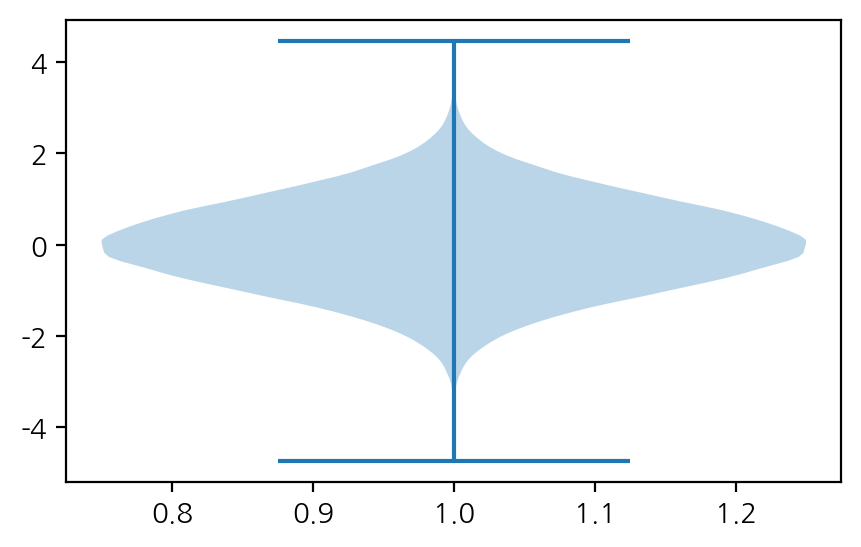

In [16]:
data = np.random.randn(100000)
plt.violinplot(data)
plt.show()

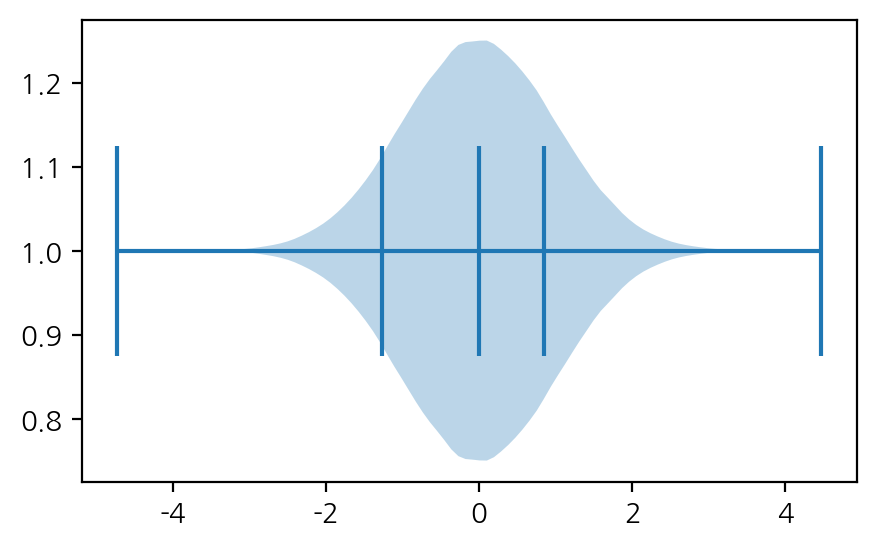

In [20]:
plt.violinplot(data, vert=False, quantiles=[.1, .5, .8])
plt.show()

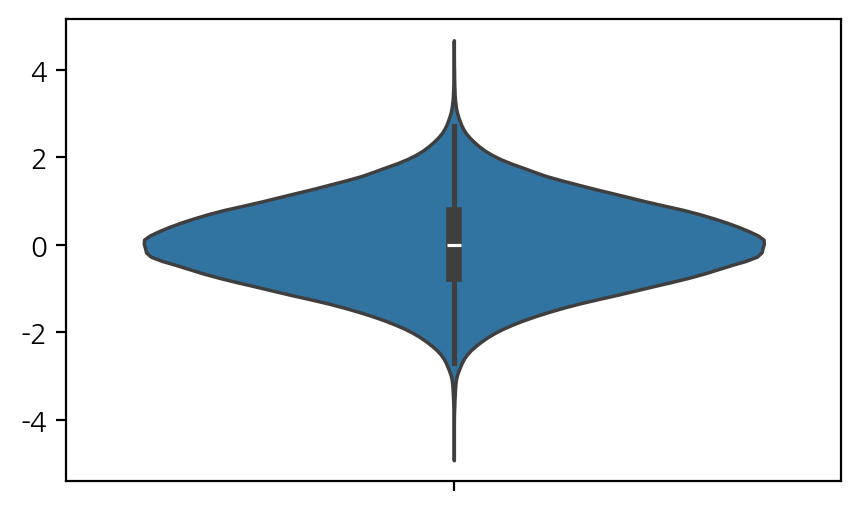

In [21]:
import seaborn as sns
sns.violinplot(data)
plt.show()


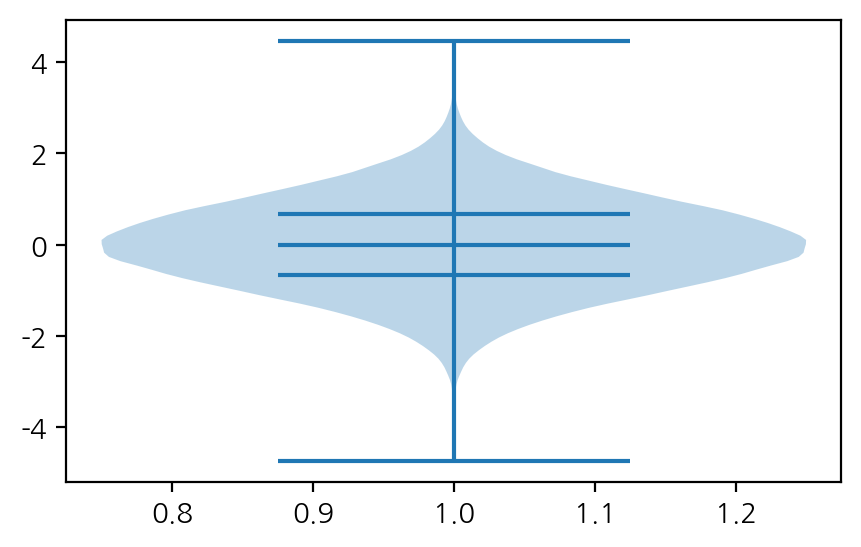

In [23]:
plt.violinplot(data, quantiles=[.25, .5, .75])
plt.show()

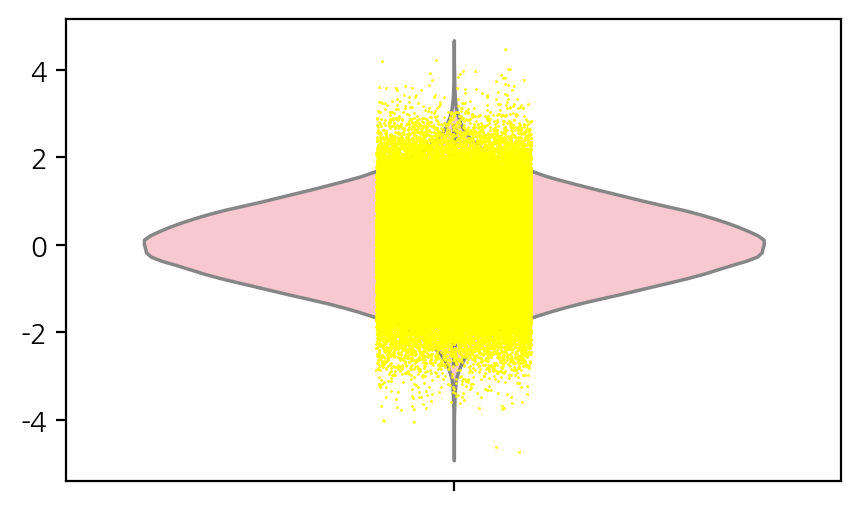

In [28]:
import seaborn as sns
sns.violinplot(data, color='pink')
sns.stripplot(data, color='yellow', size=1)
plt.show()

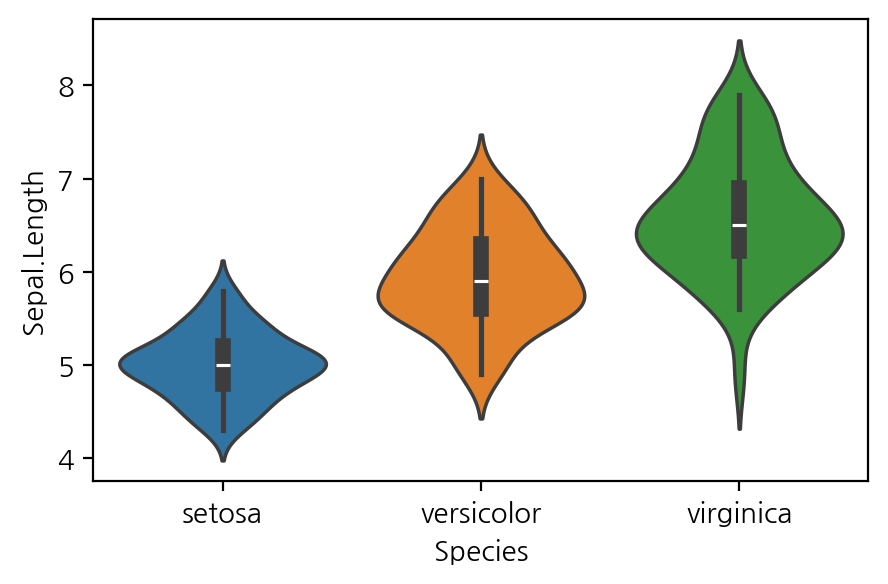

In [29]:
import seaborn as sns
sns.violinplot(iris, x='Species', y='Sepal.Length', hue='Species');

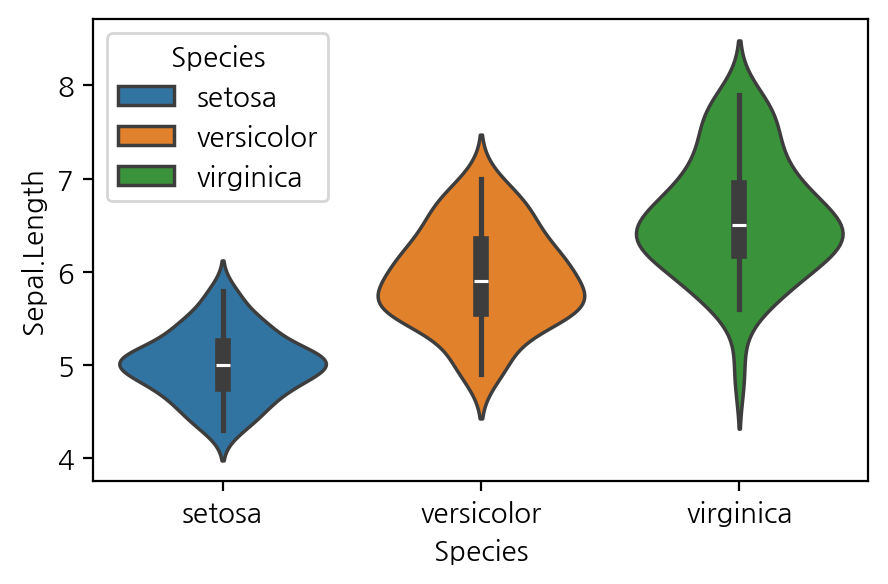

In [30]:
sns.violinplot(iris, x='Species', y='Sepal.Length', hue='Species', legend='full');

In [32]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [33]:
display_side_by_side(mtc.head(), mtc.tail())

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8


In [34]:
mincar = mtc.iloc[:, :4]
display_side_by_side(mincar.head(), mincar.tail())

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175
,mpg,cyl,disp,hp
Lotus Europa,30.4,4,95.1,113
Ford Pantera L,15.8,8,351.0,264
Ferrari Dino,19.7,6,145.0,175
Maserati Bora,15.0,8,301.0,335


In [36]:
mtc.columns[:4].to_list()

['mpg', 'cyl', 'disp', 'hp']

In [39]:
mtc[['mpg', 'cyl']]

,mpg,cyl
Mazda RX4,21.0,6
Mazda RX4 Wag,21.0,6
Datsun 710,22.8,4
Hornet 4 Drive,21.4,6
Hornet Sportabout,18.7,8
Valiant,18.1,6
Duster 360,14.3,8
Merc 240D,24.4,4
Merc 230,22.8,4
Merc 280,19.2,6


In [35]:
mcar = mtc[mtc.columns[:4].to_list()]
display_side_by_side(mincar.head(), mcar.head())

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175
,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110


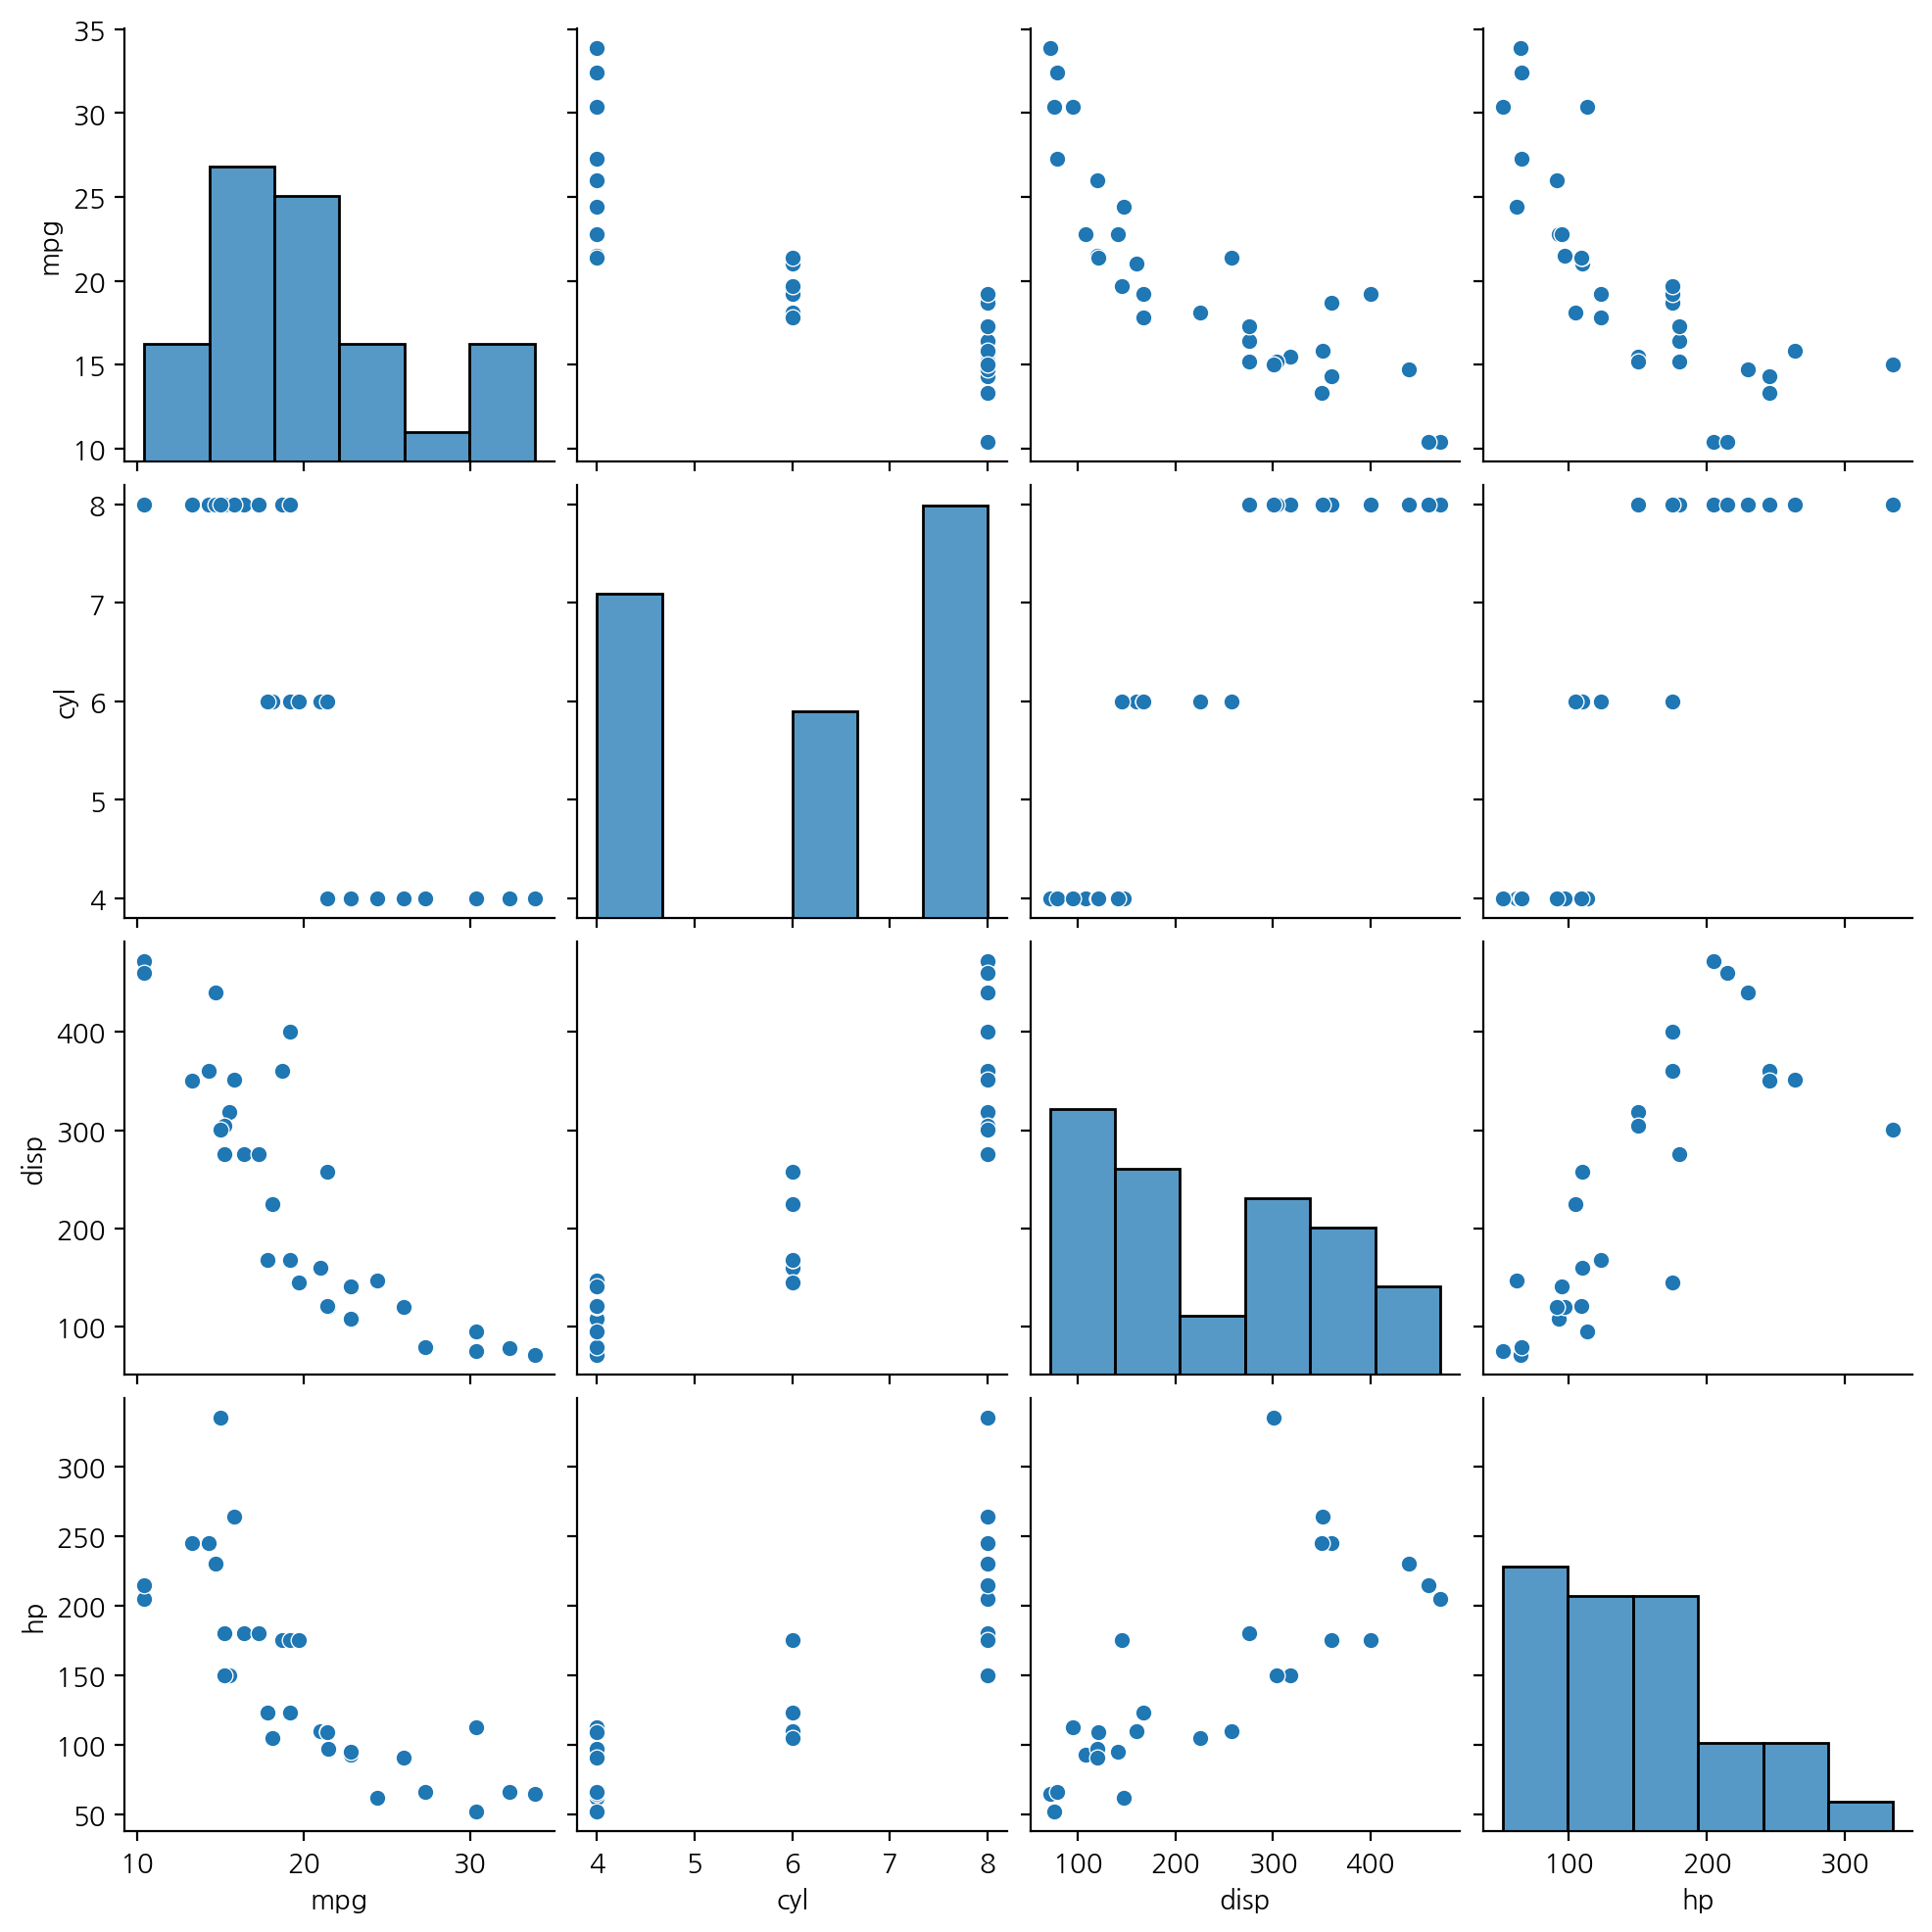

In [40]:
import seaborn as sns
sns.pairplot(mcar);

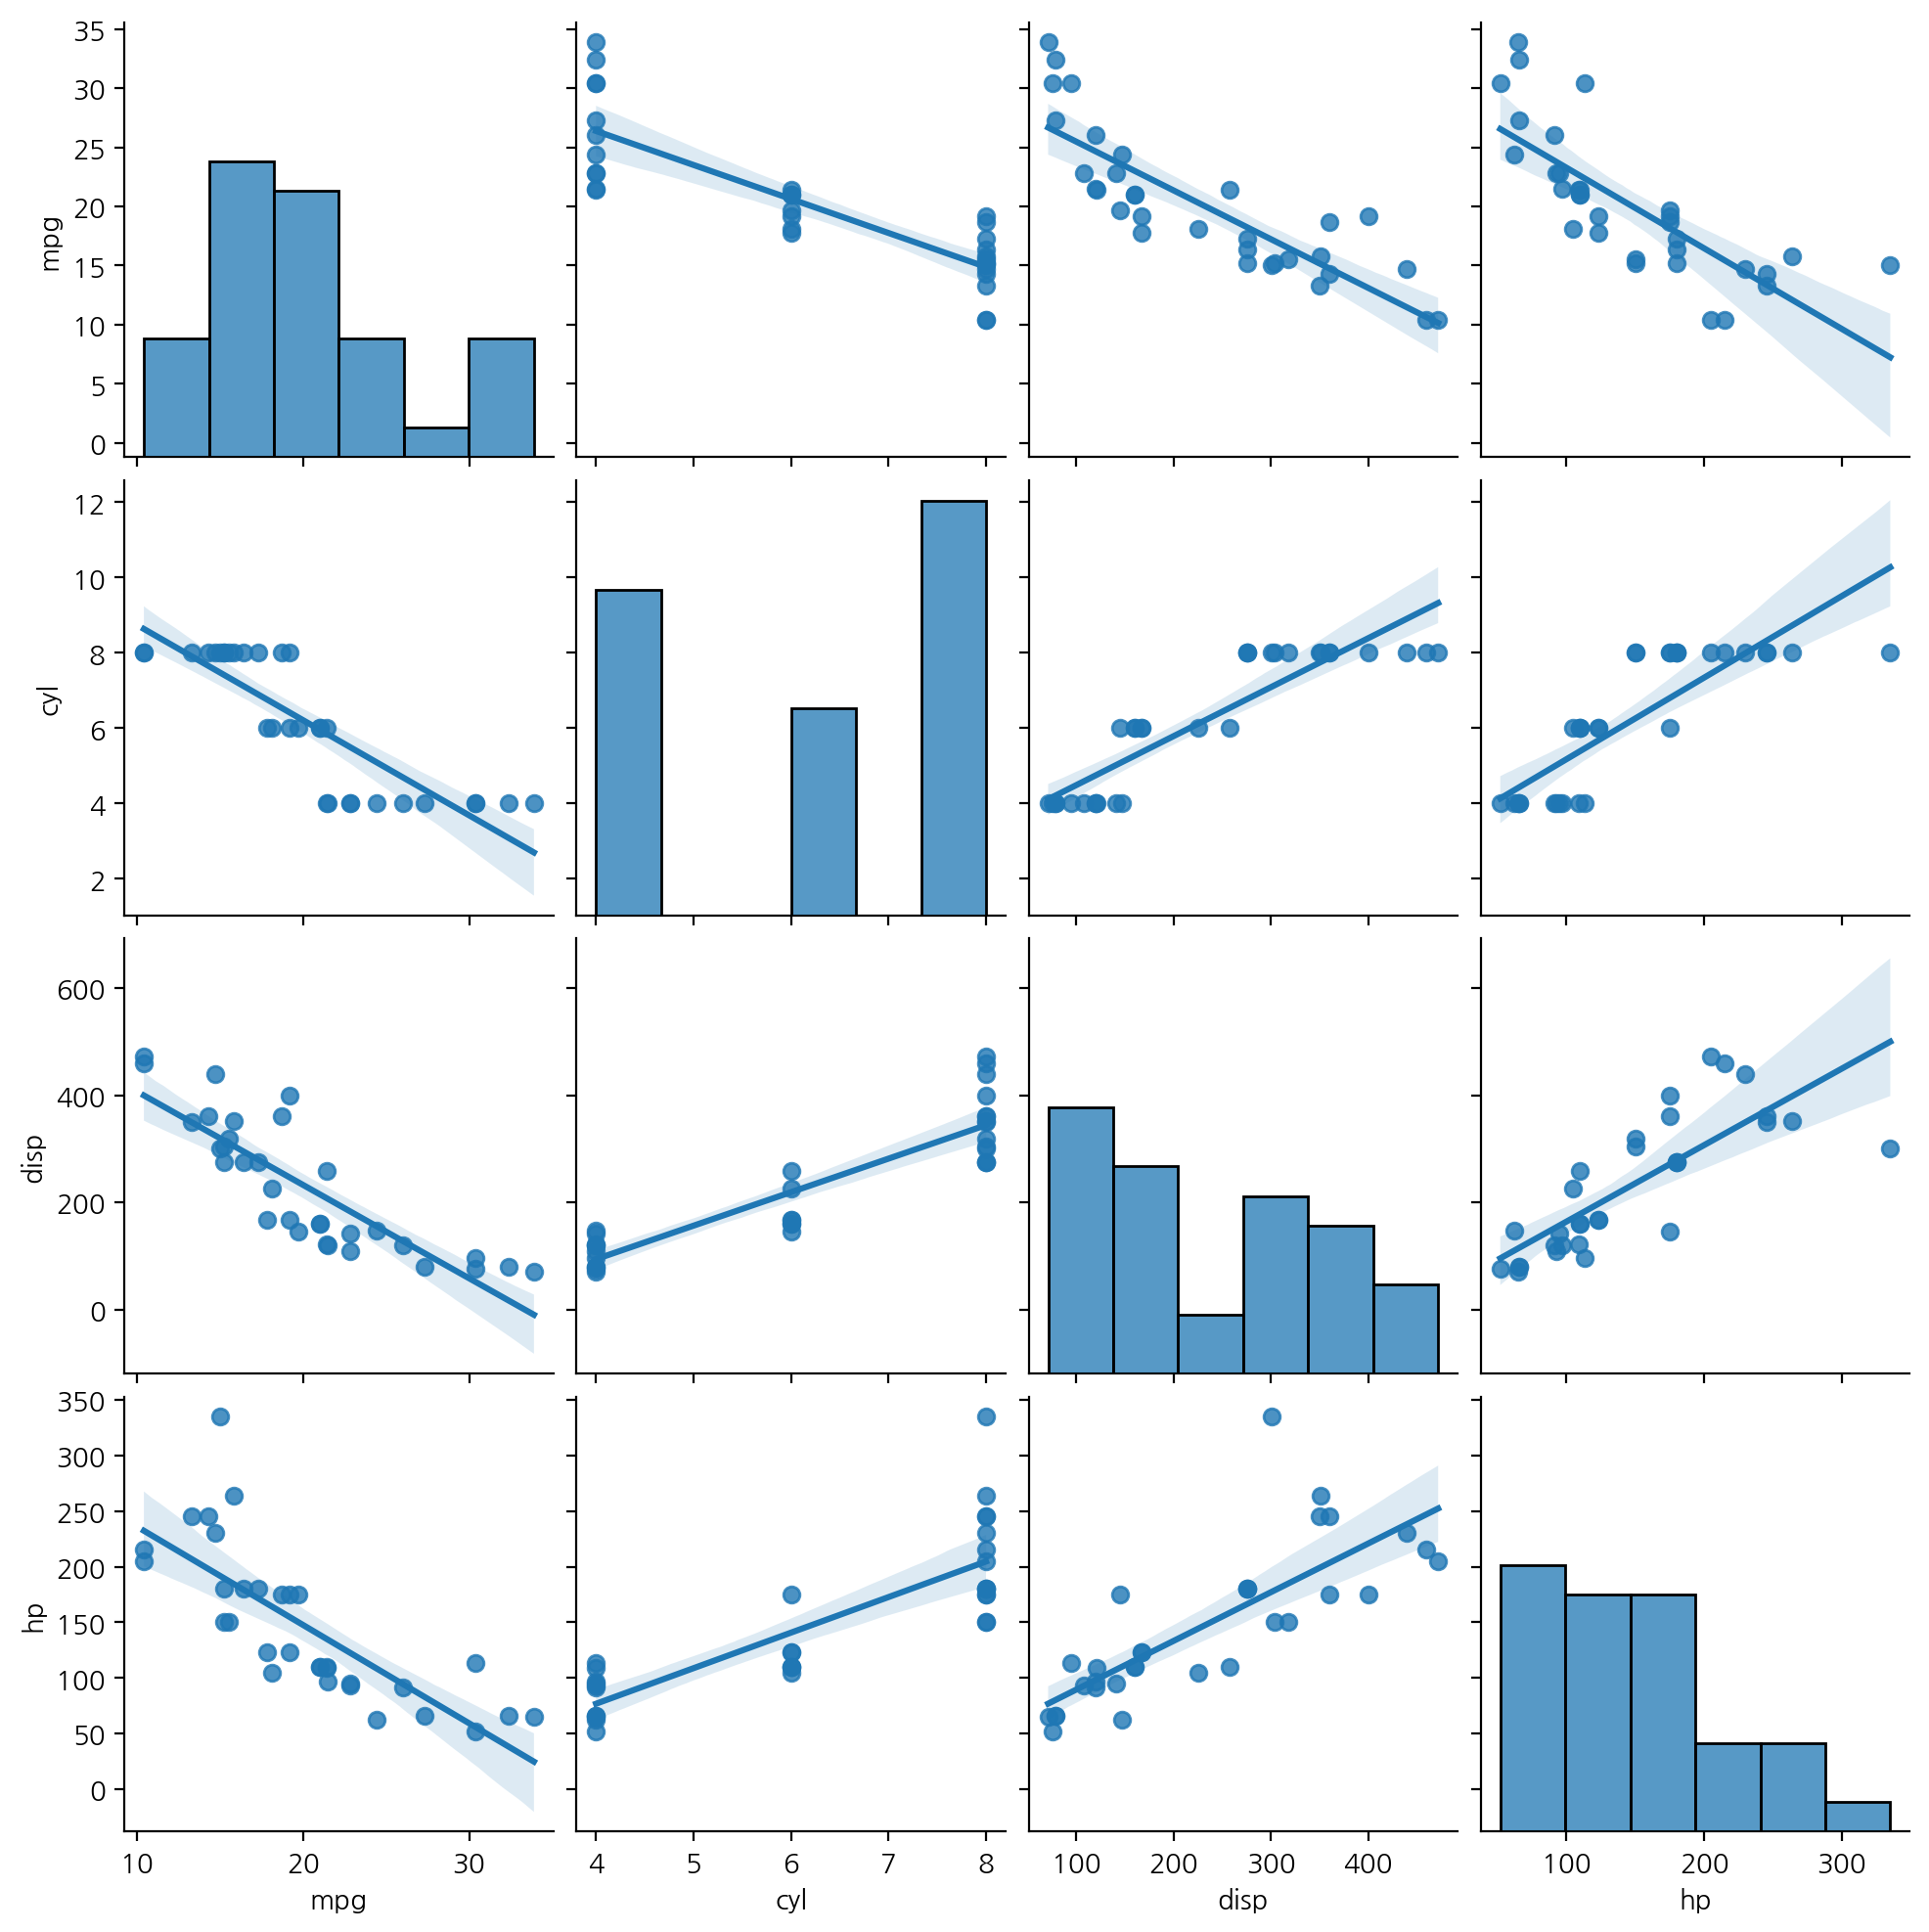

In [41]:
sns.pairplot(mcar, kind='reg');

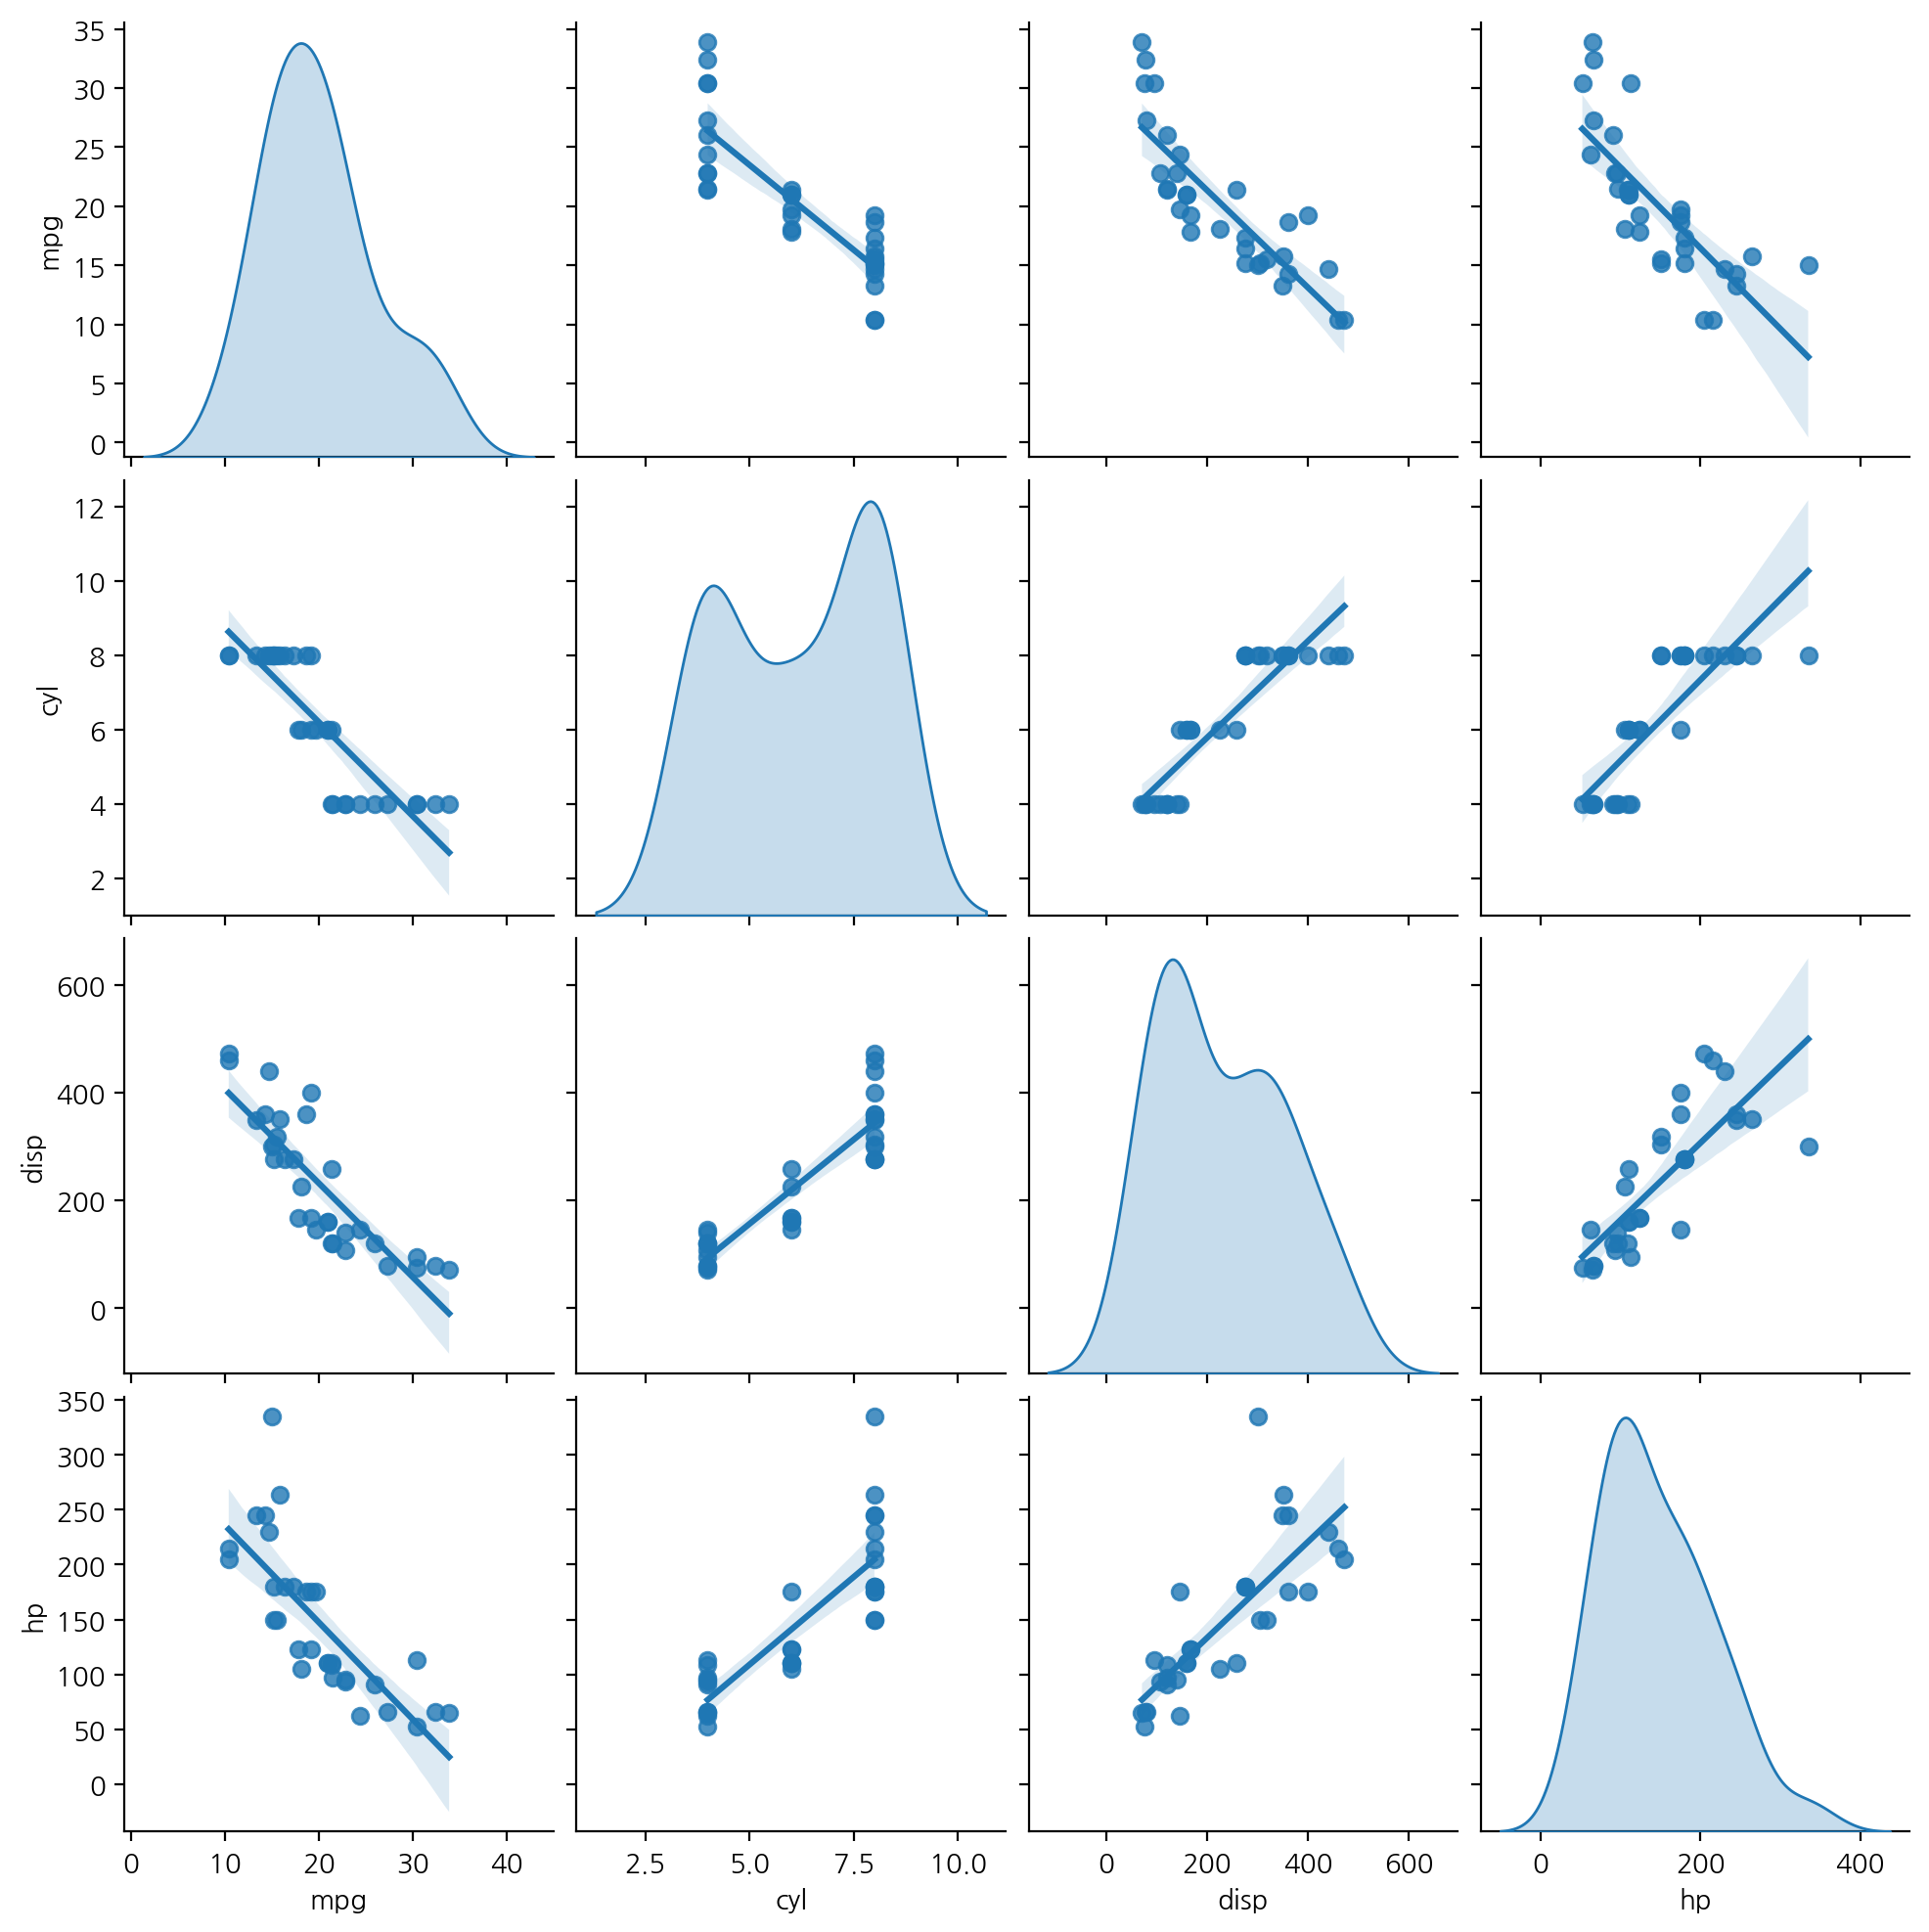

In [42]:
sns.pairplot(mcar, kind='reg', diag_kind='kde');

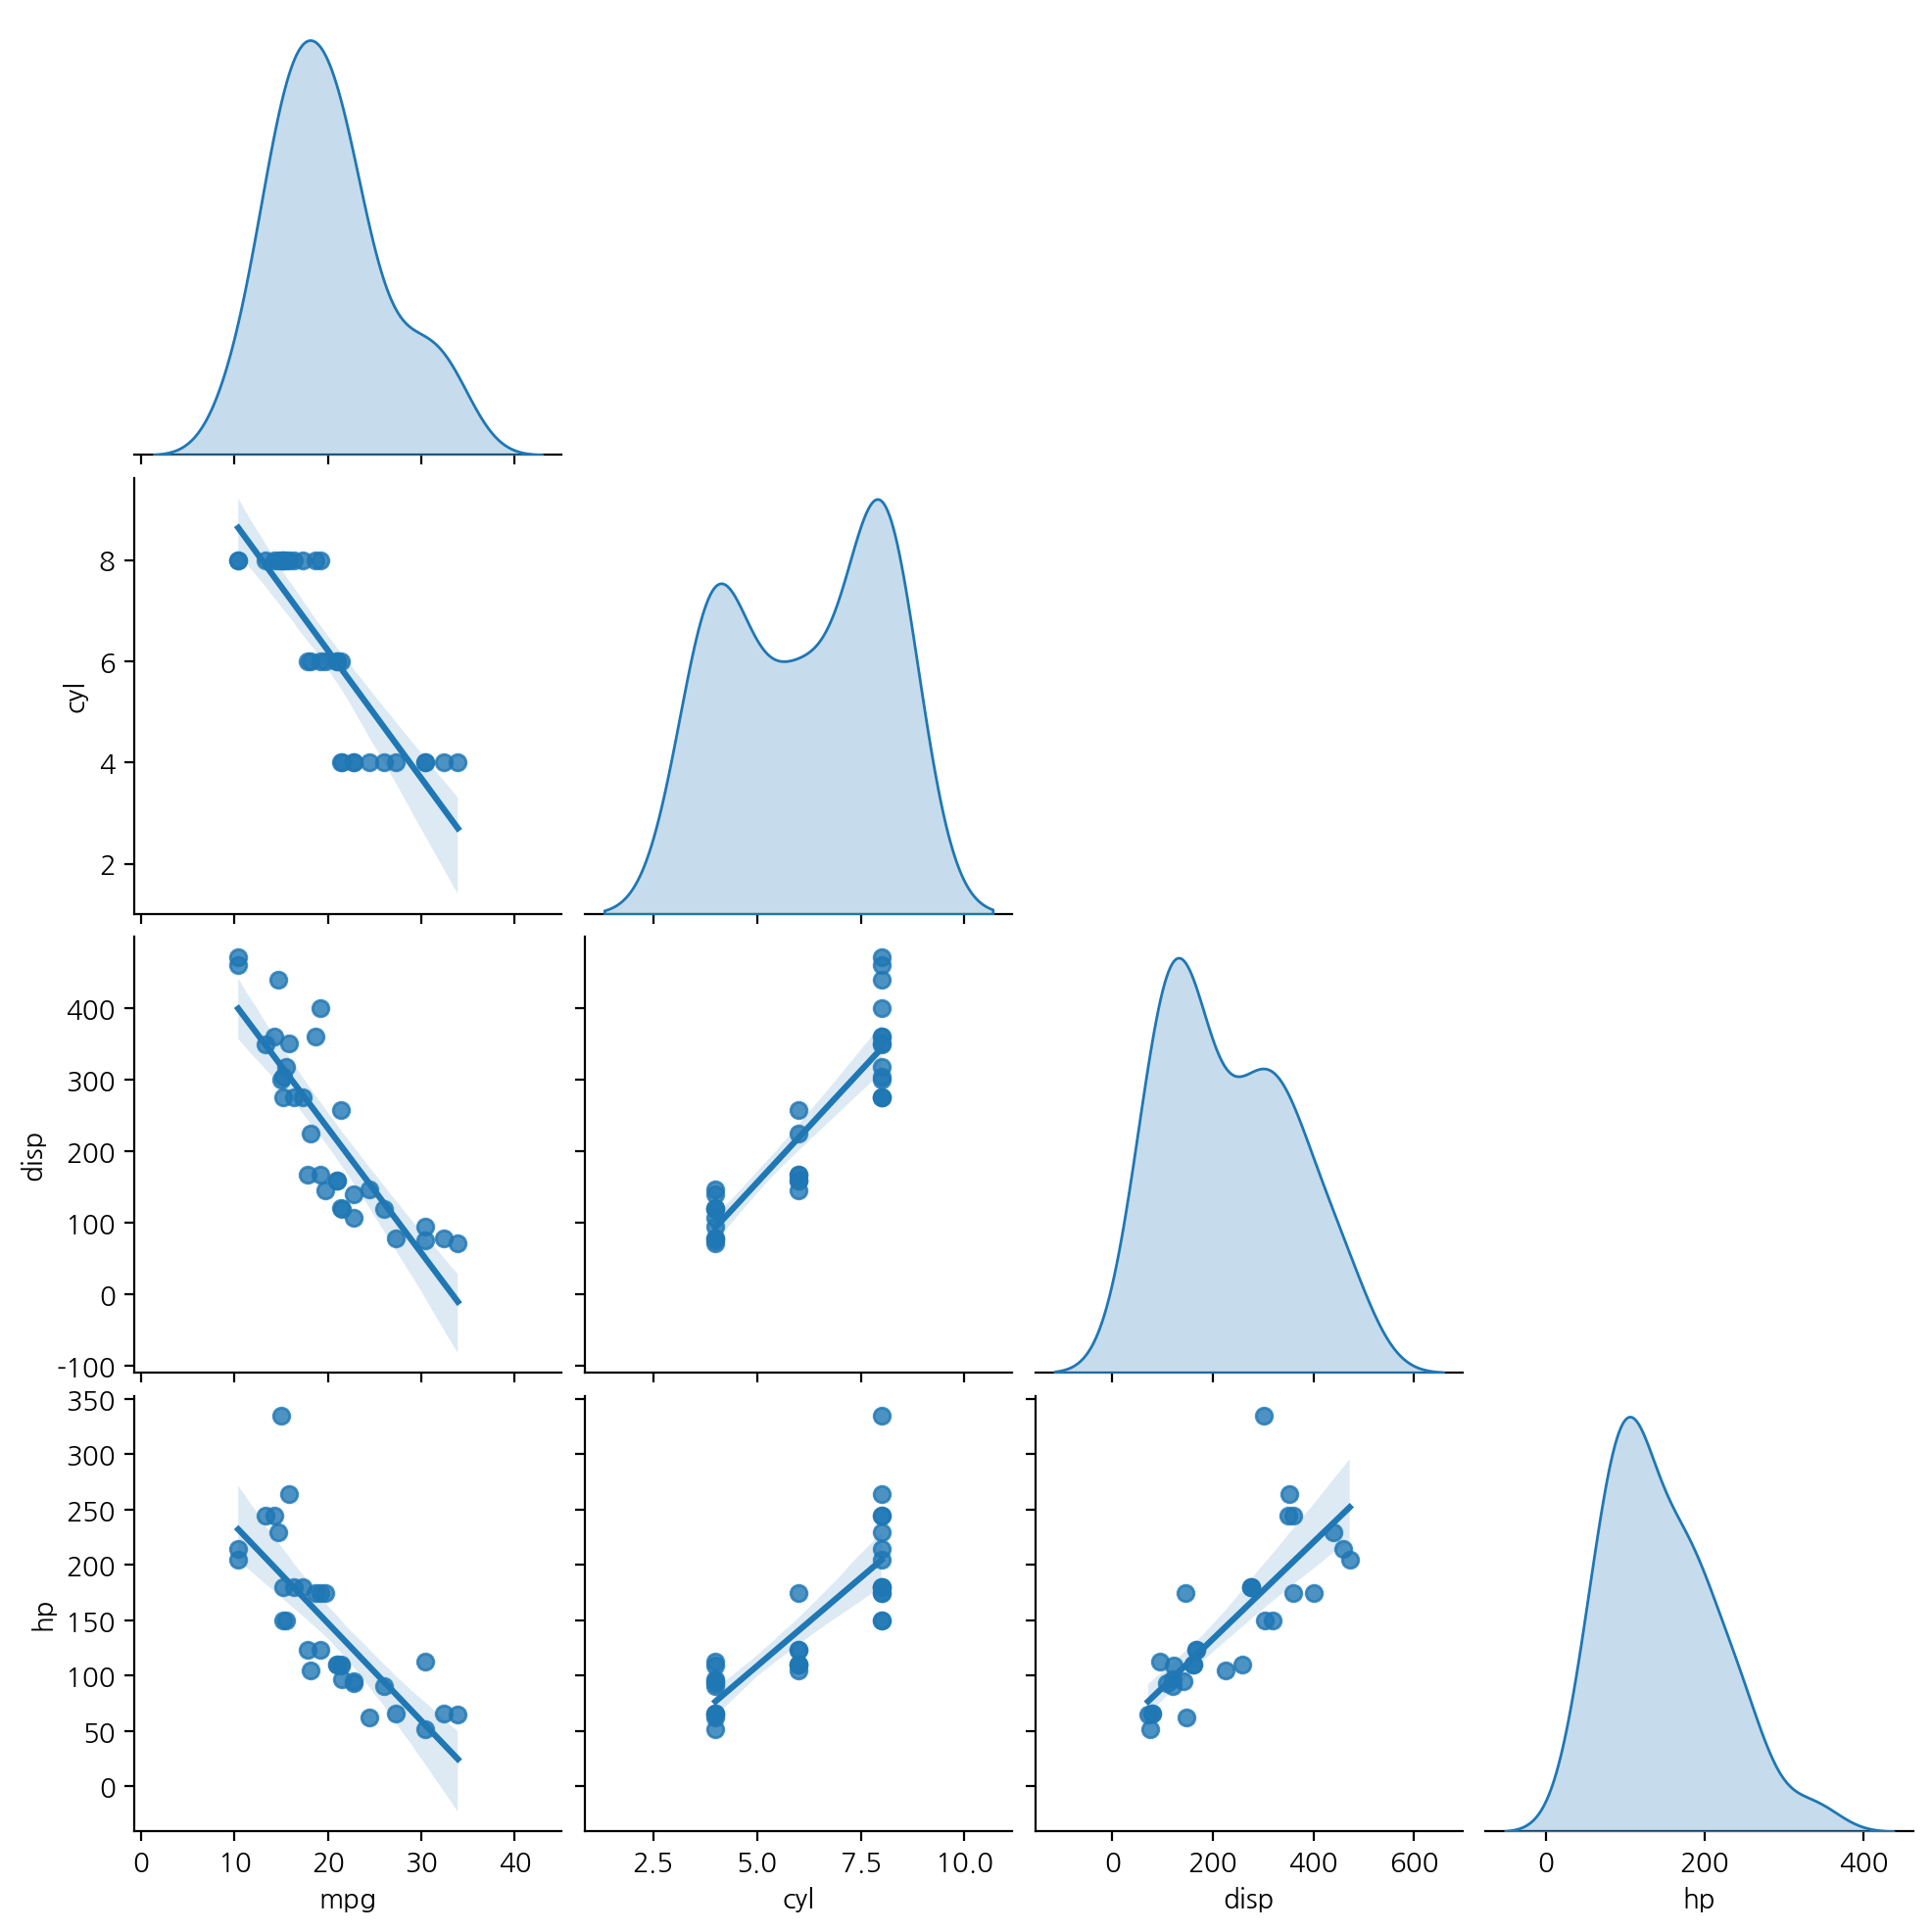

In [43]:
sns.pairplot(mcar, kind='reg', diag_kind='kde', corner=True);

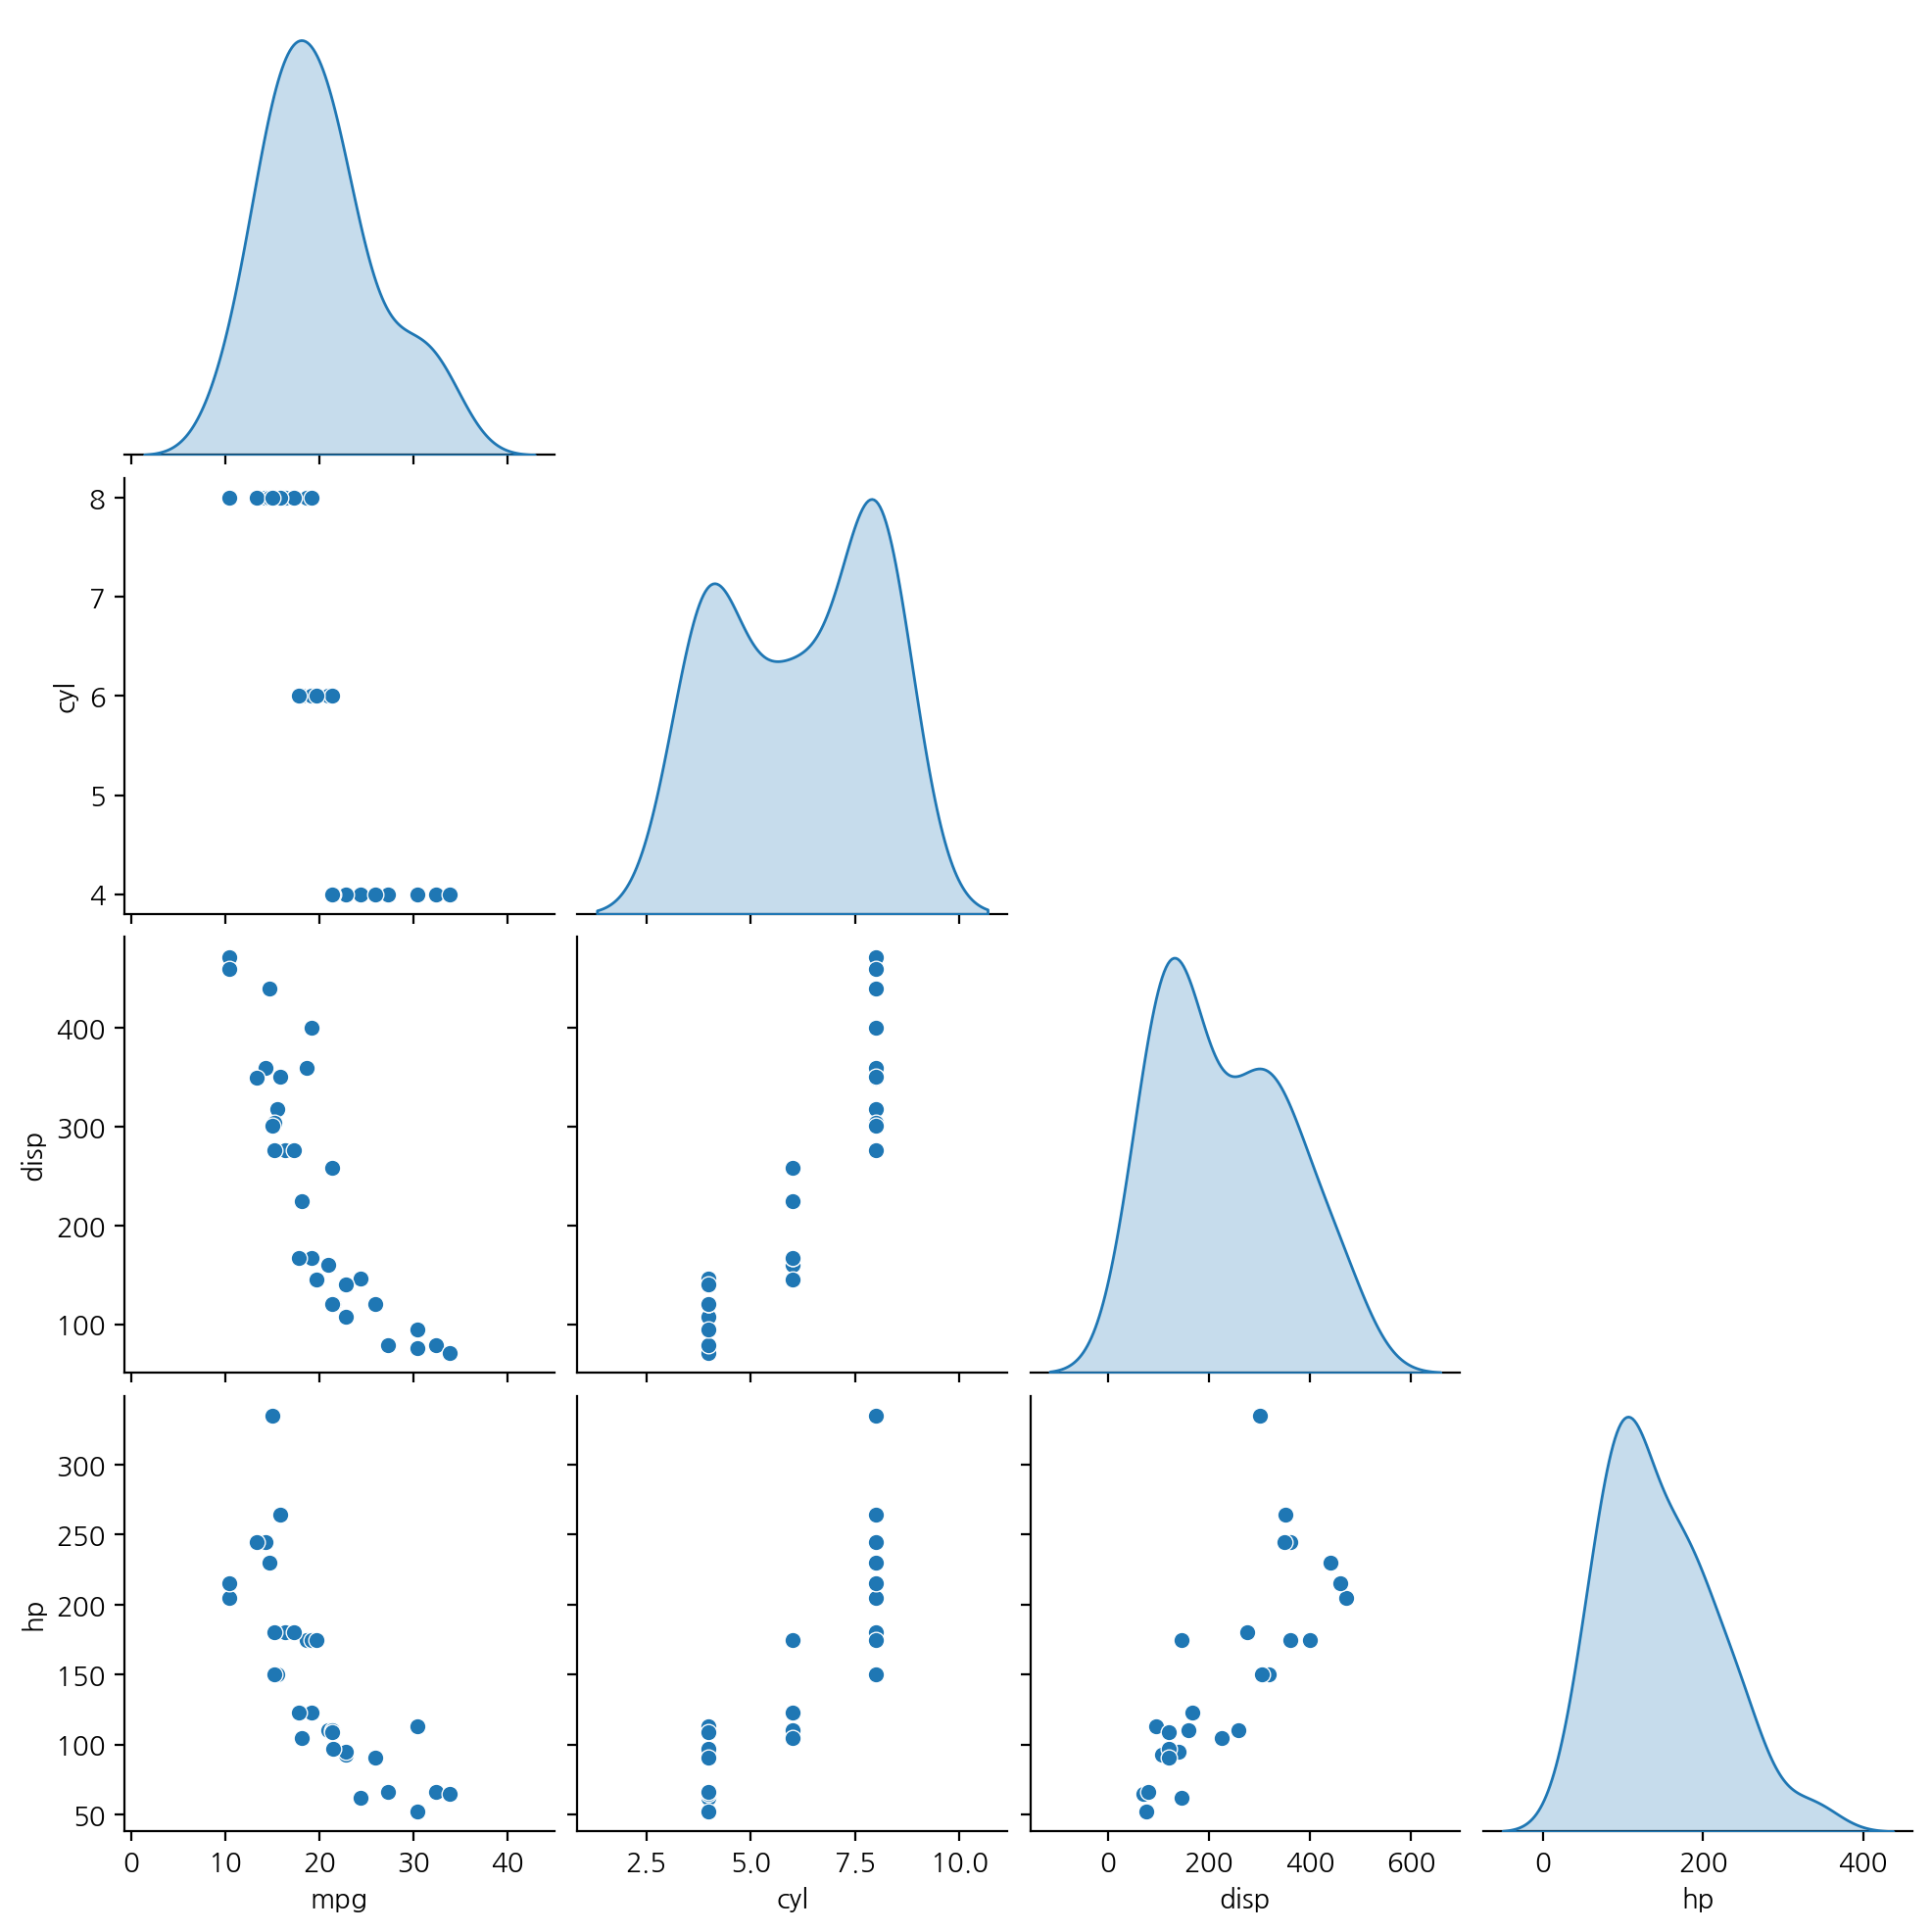

In [44]:
sns.pairplot(mcar, diag_kind='kde', corner=True);

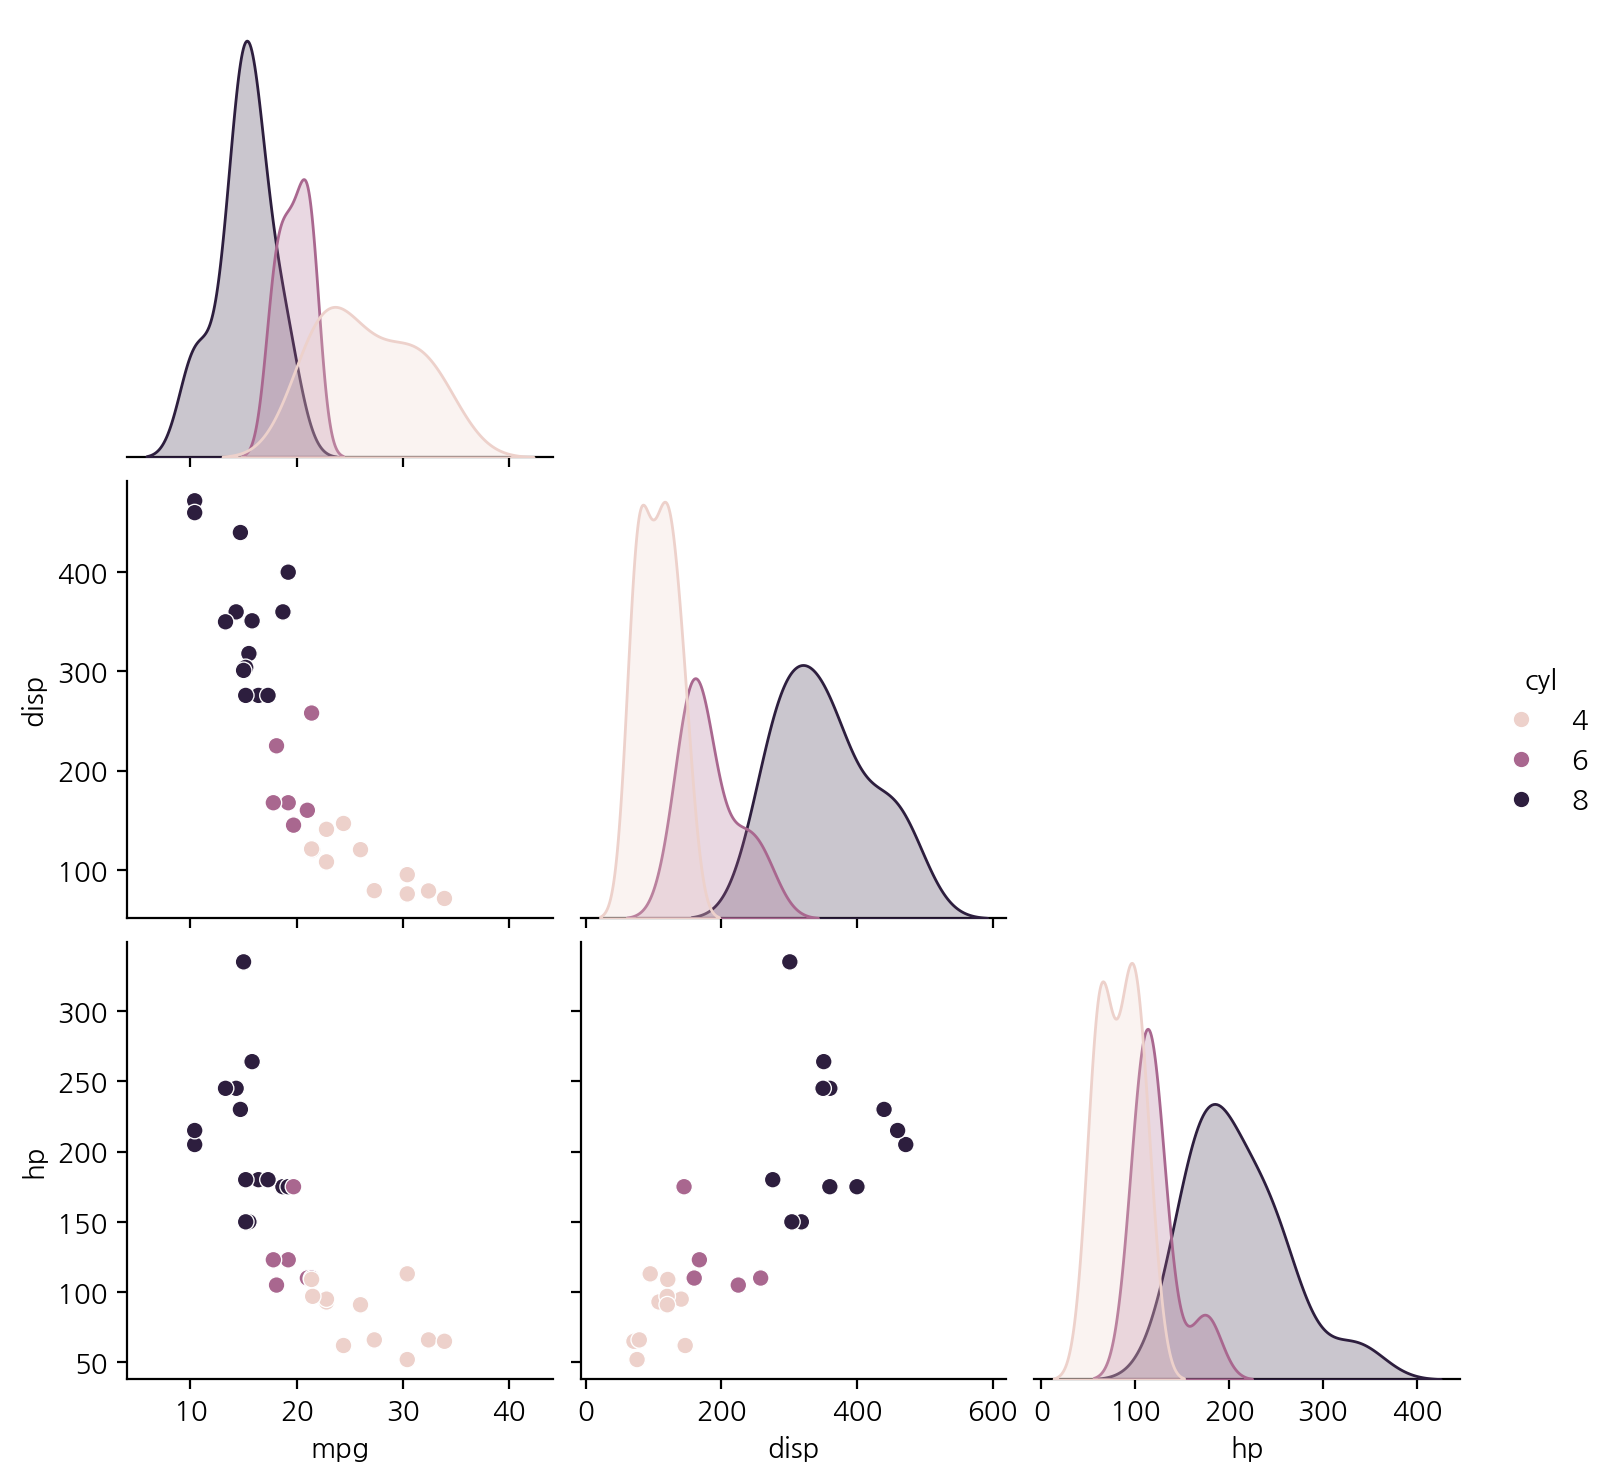

In [45]:
sns.pairplot(mcar, diag_kind='kde', corner=True, hue='cyl');

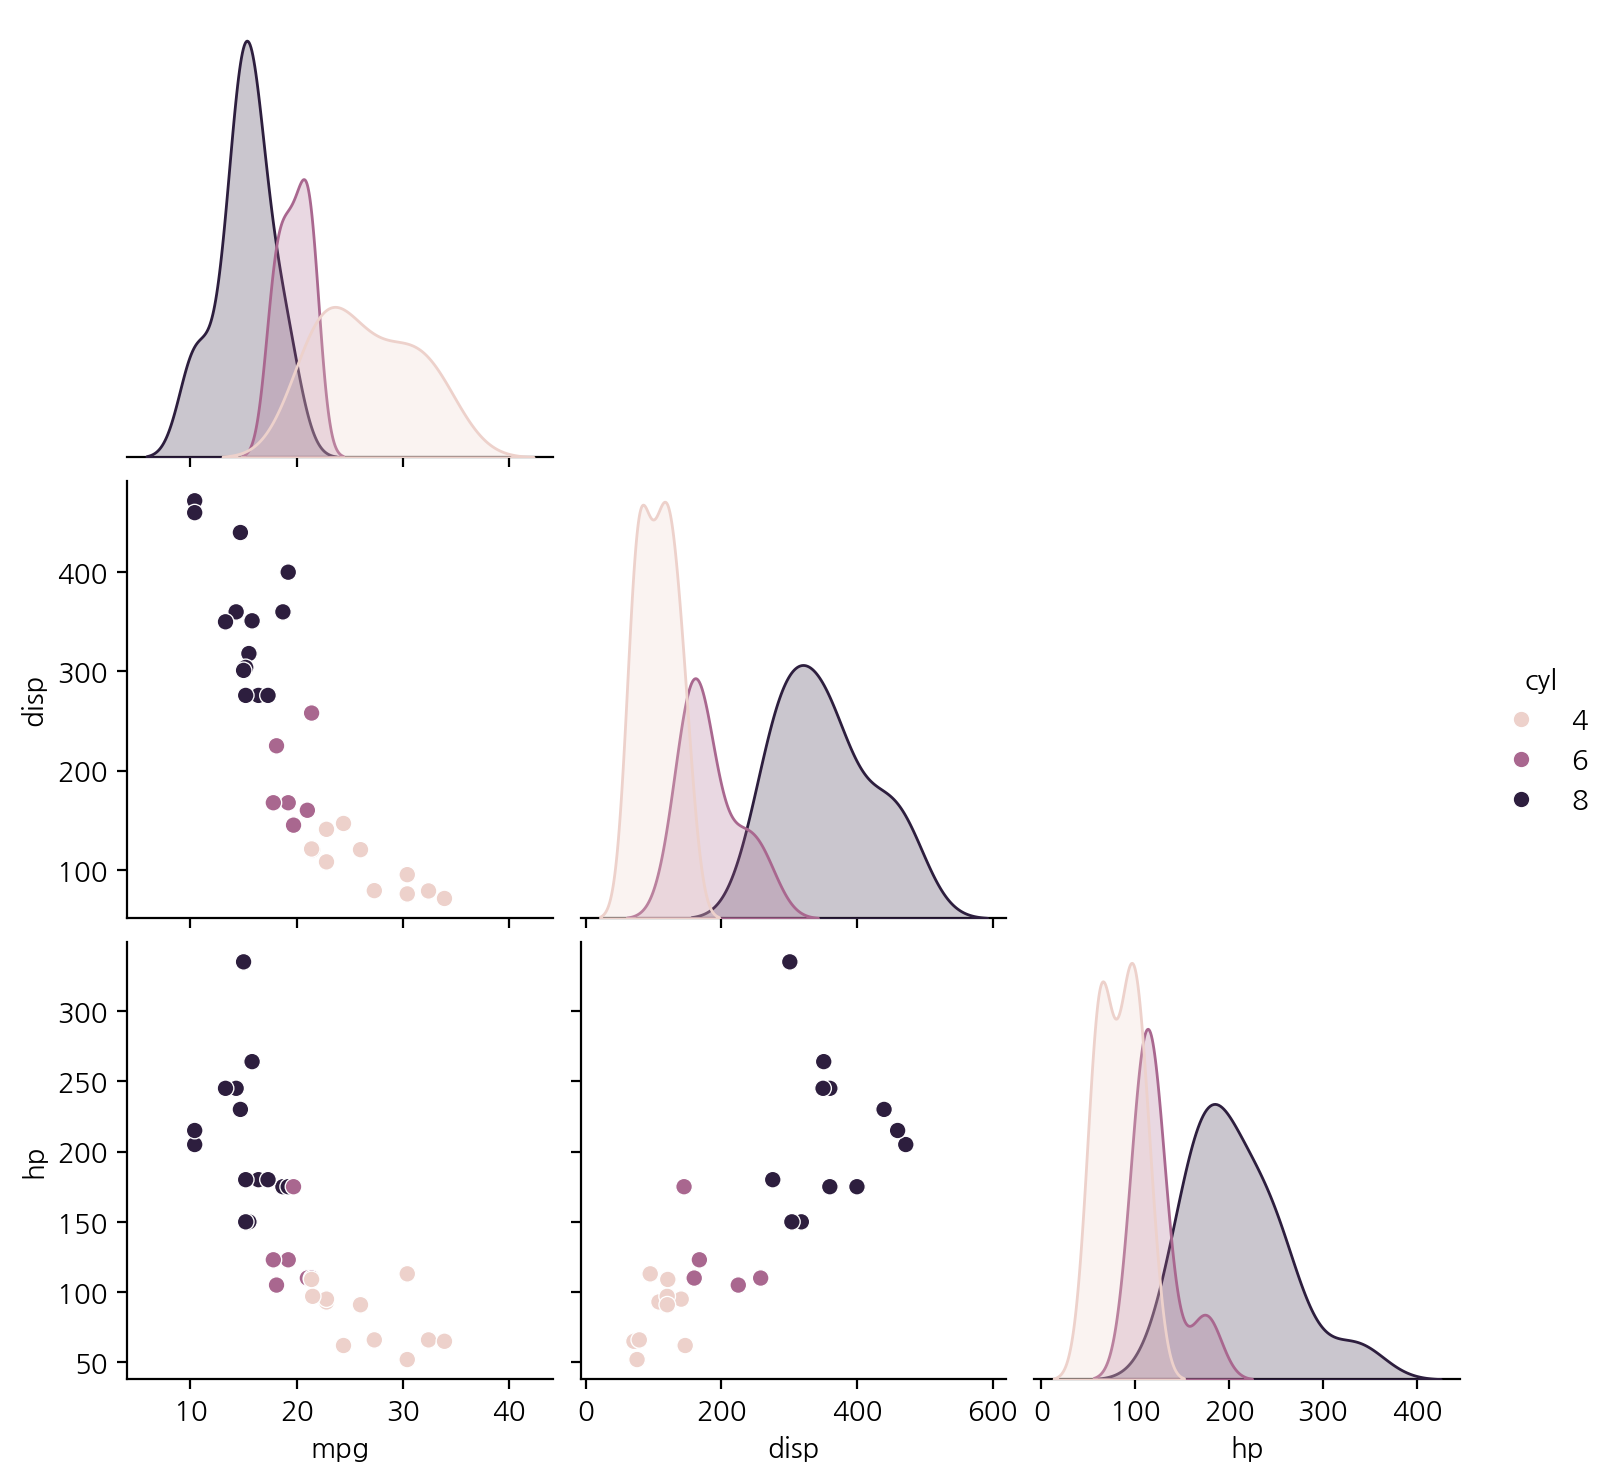

In [46]:
sns.pairplot(mcar, corner=True, hue='cyl');

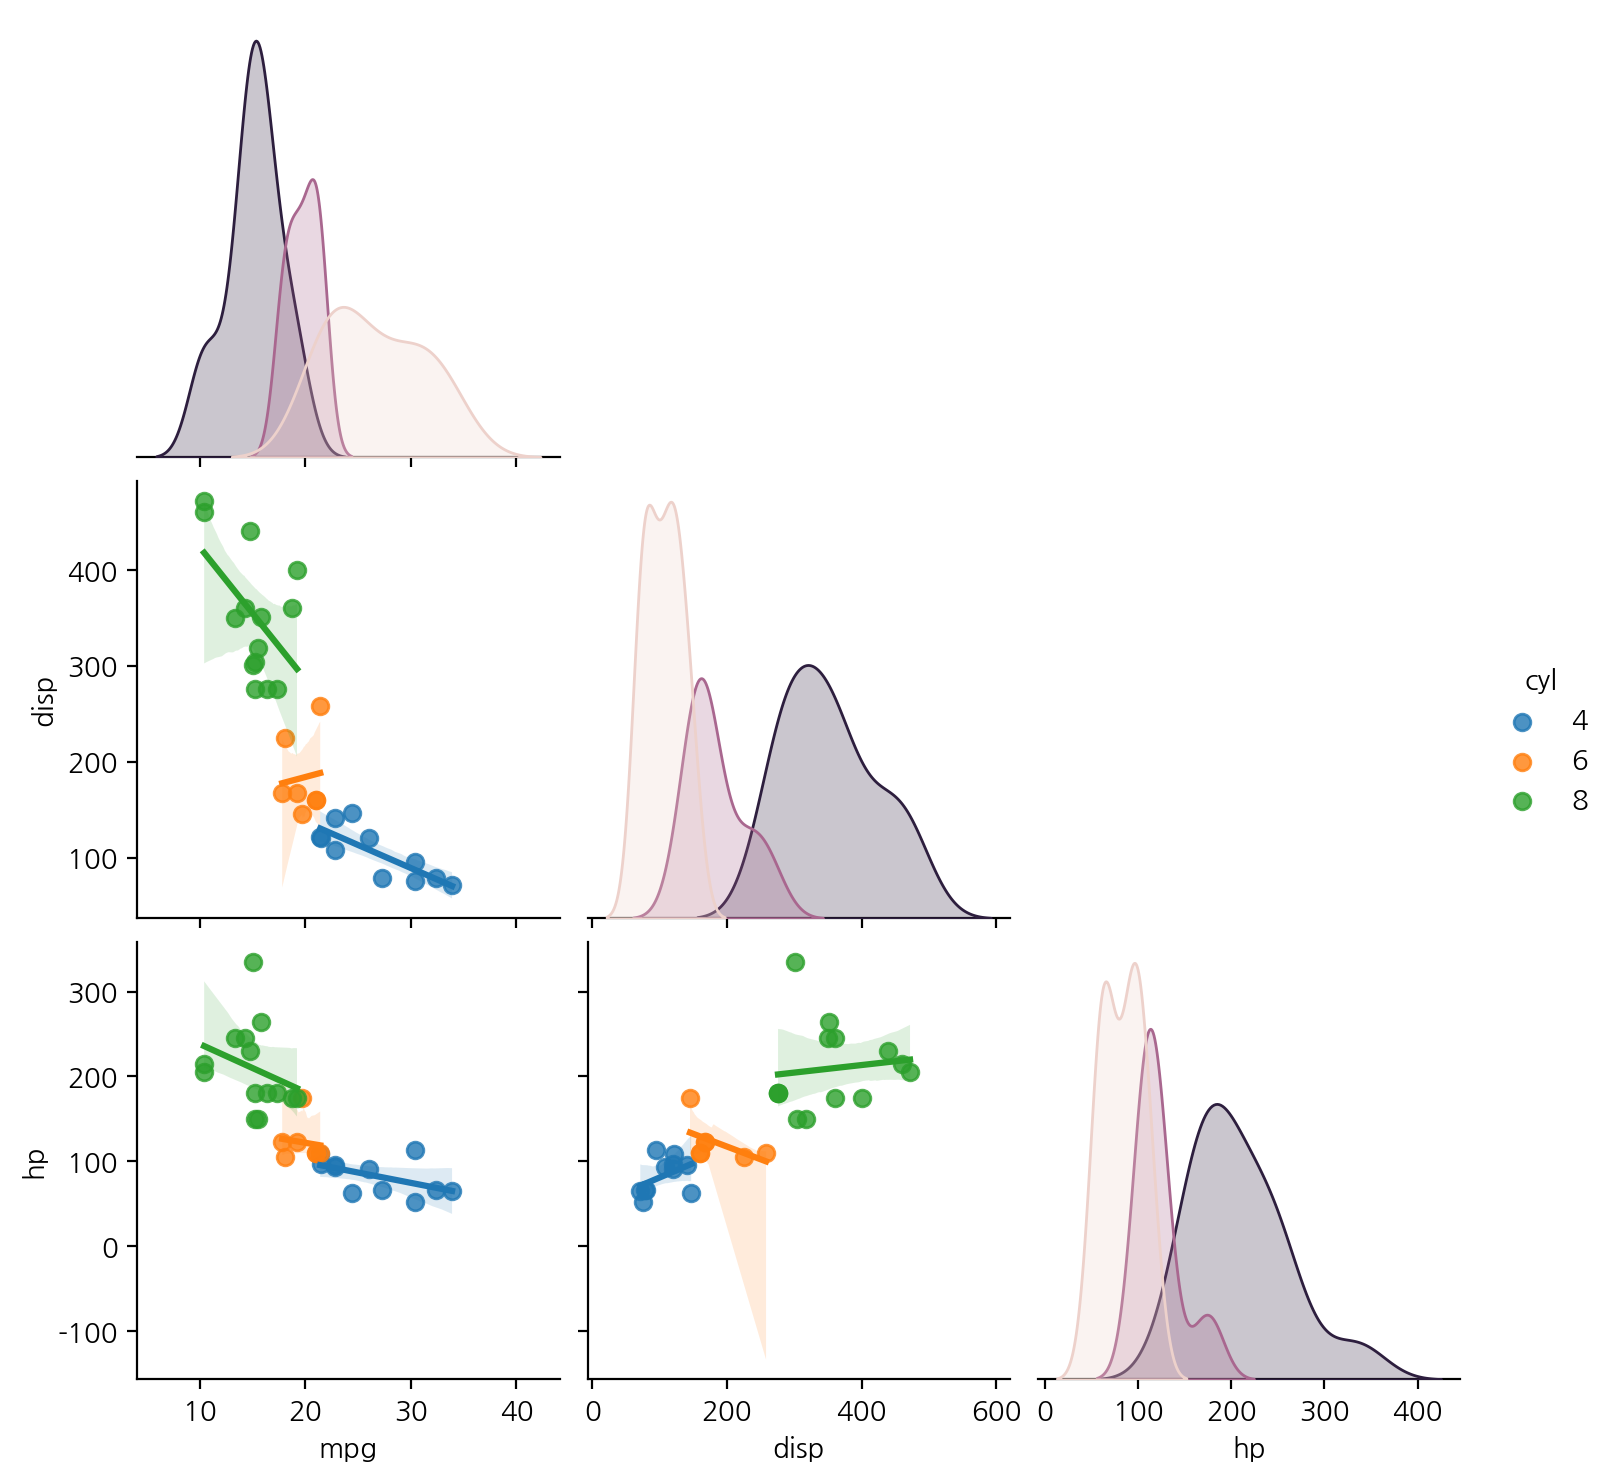

In [47]:
sns.pairplot(mcar, diag_kind='kde', kind='reg', corner=True, hue='cyl');

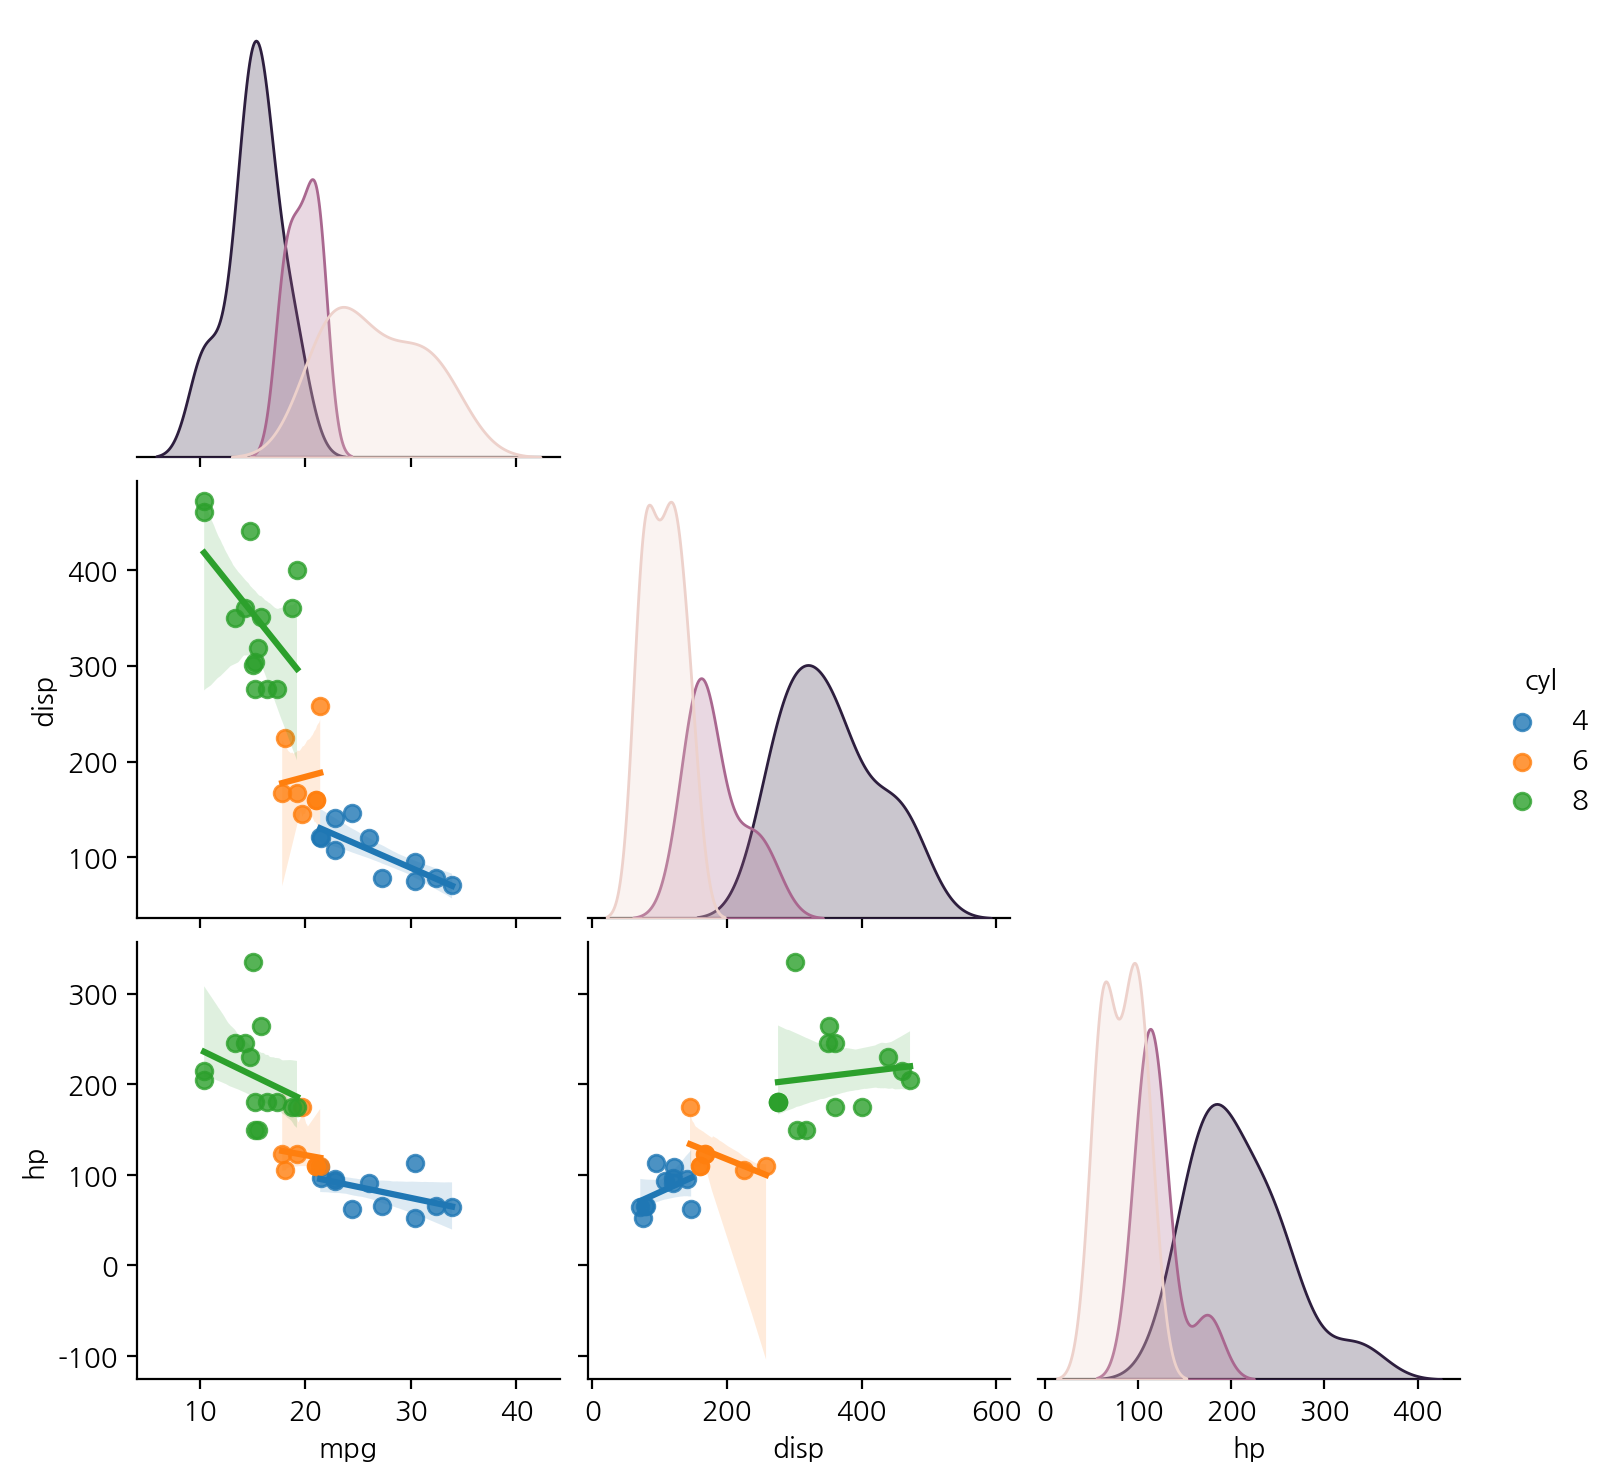

In [48]:
sns.pairplot(mcar, kind='reg', corner=True, hue='cyl');

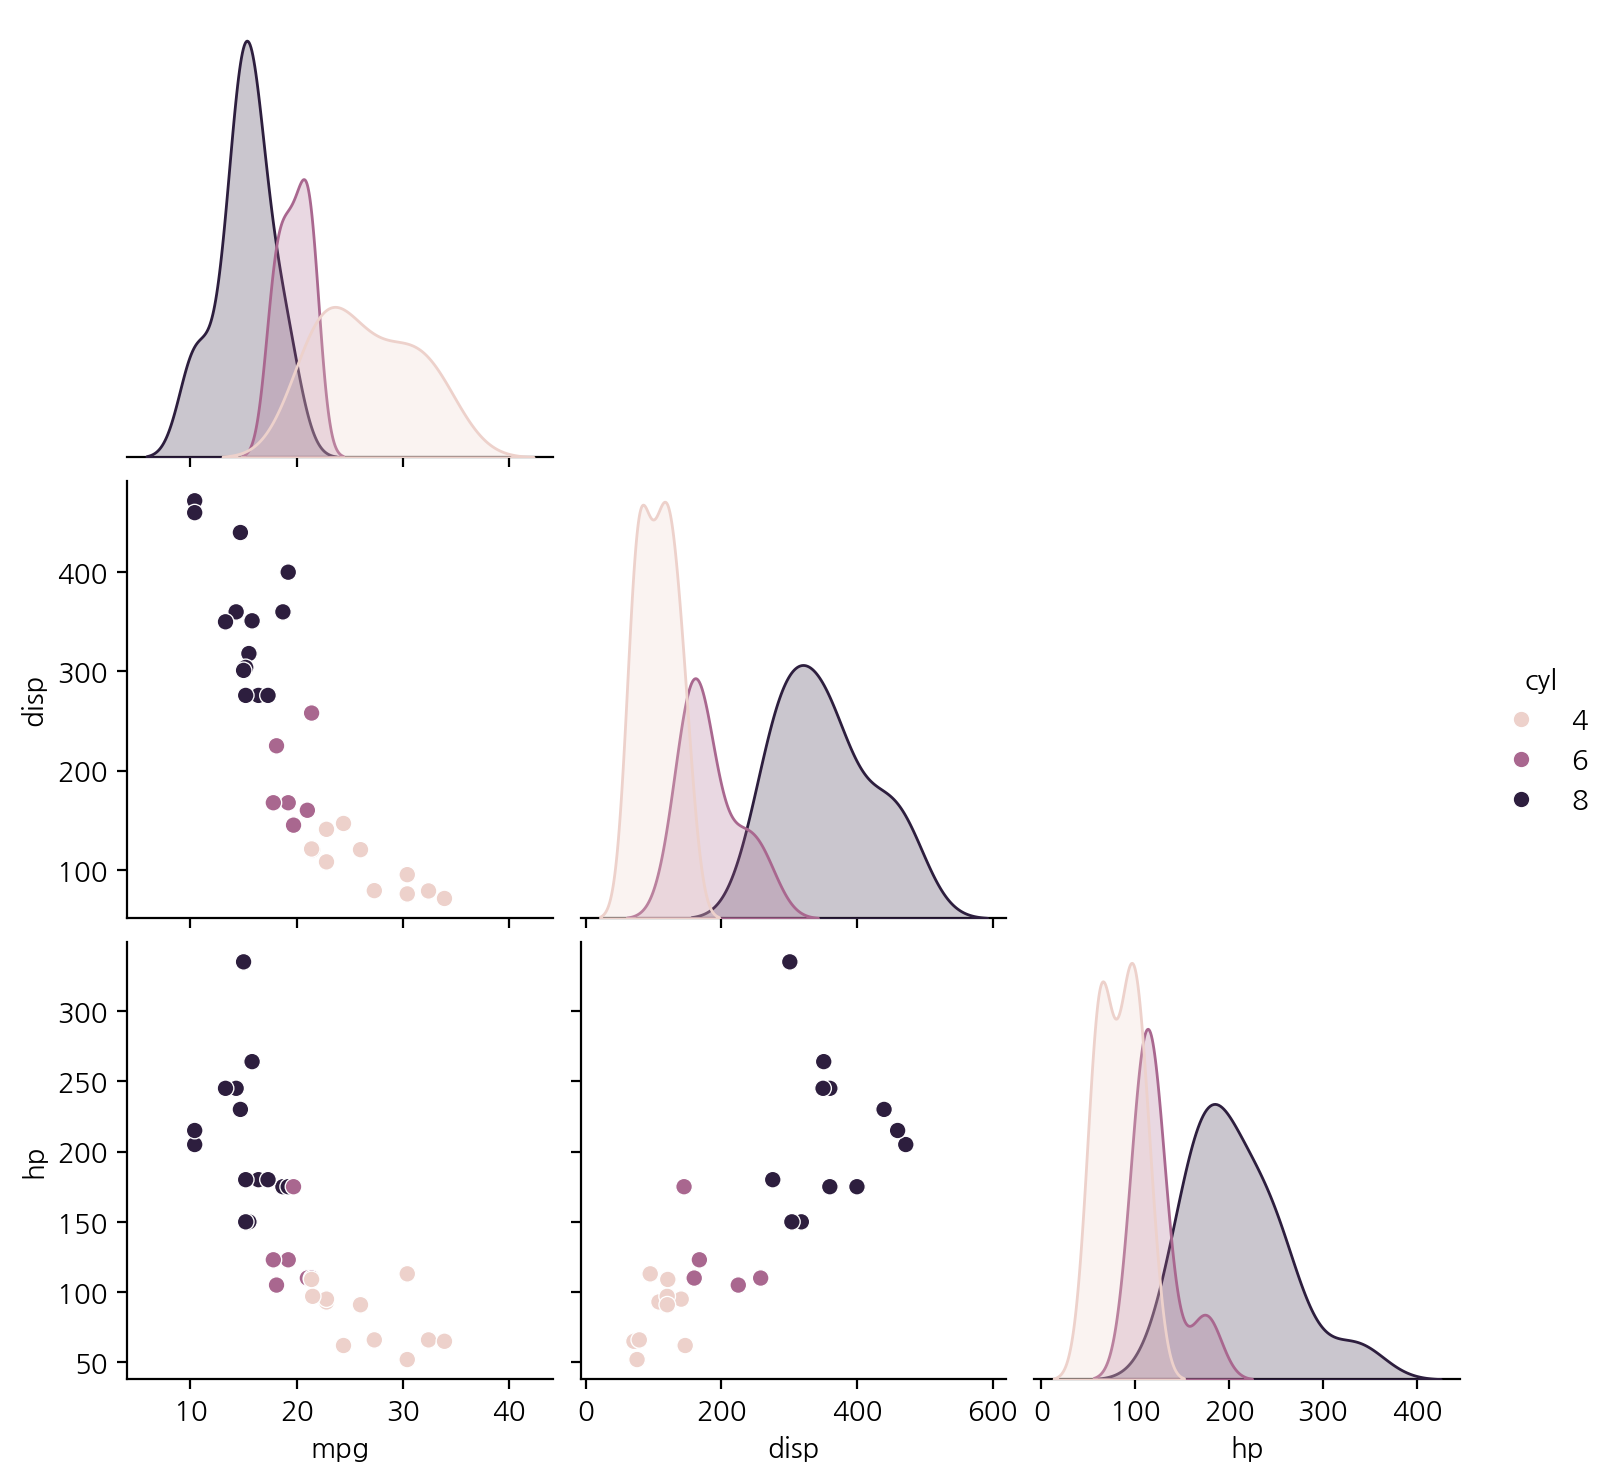

In [51]:
sns.pairplot(mcar, corner=True, hue='cyl');

In [54]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [55]:
pd.set_option('display.precision', 2)

In [57]:
iris[iris.columns[:-1].to_list()].head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [58]:
corr = iris[iris.columns[:-1].to_list()].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


<Axes: >

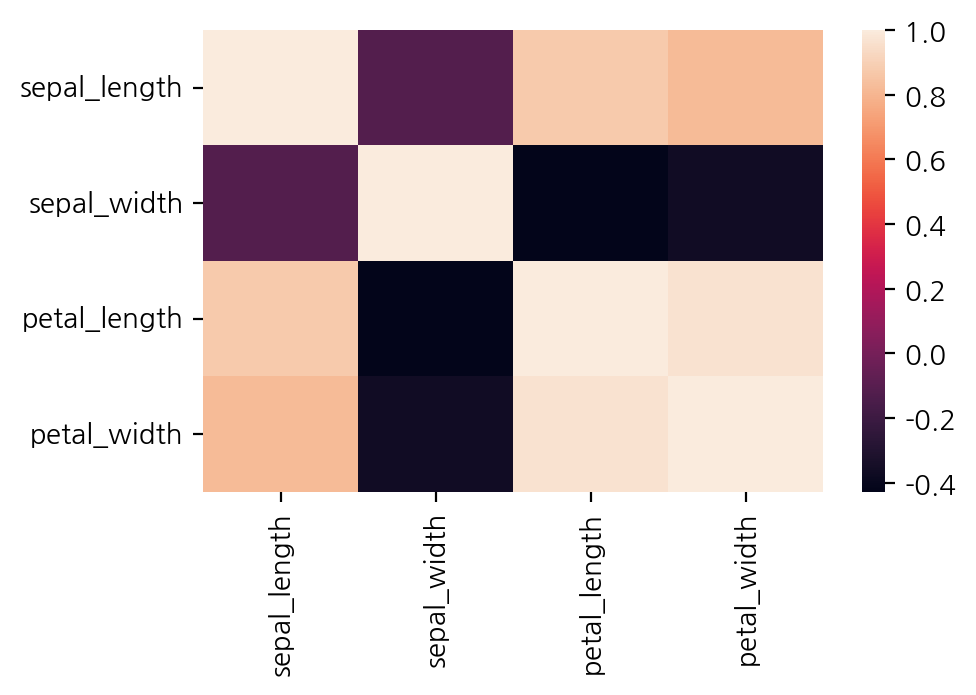

In [59]:
sns.heatmap(corr)

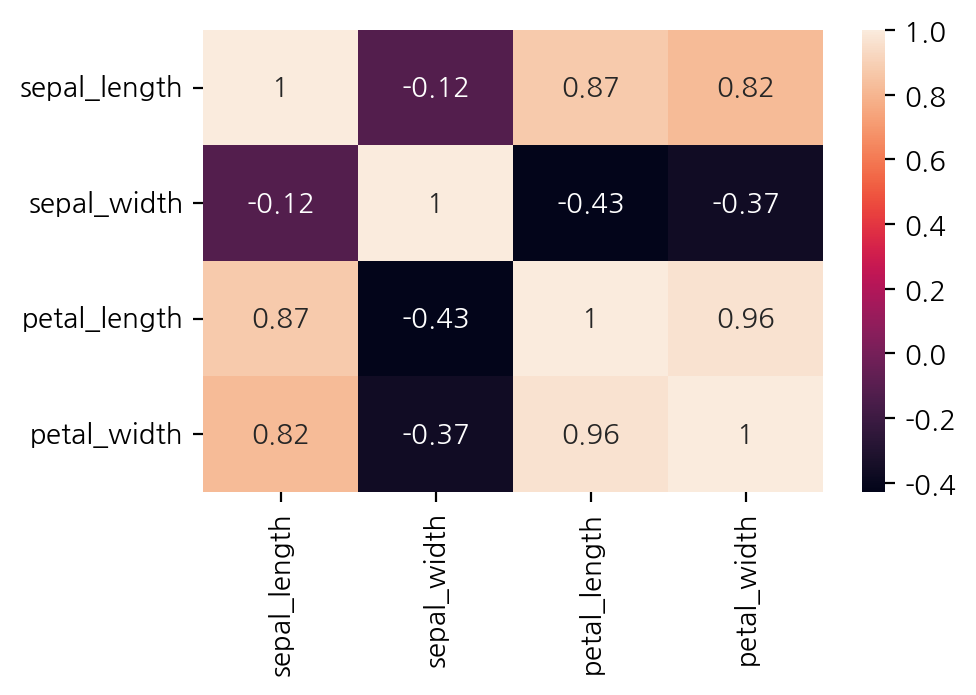

In [61]:
sns.heatmap(corr, annot=True)
plt.show()

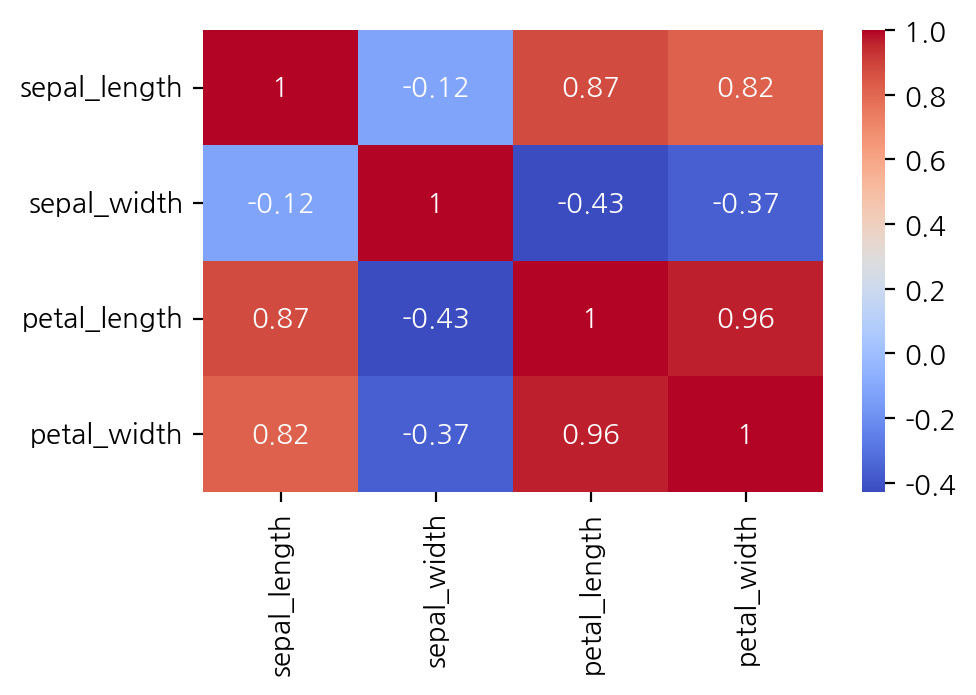

In [62]:
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

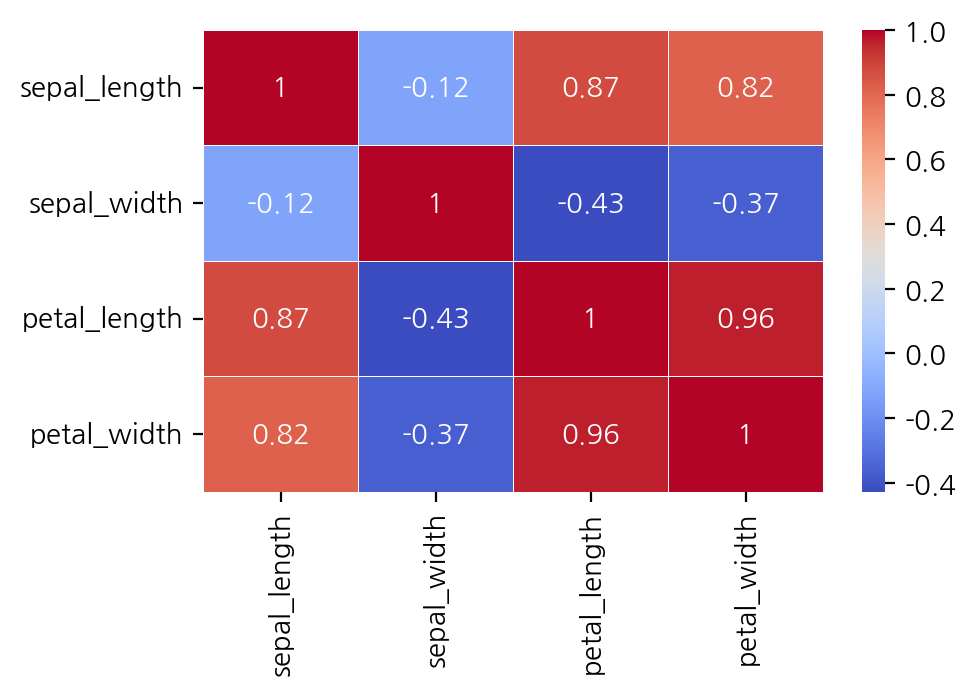

In [63]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=.2)
plt.show()

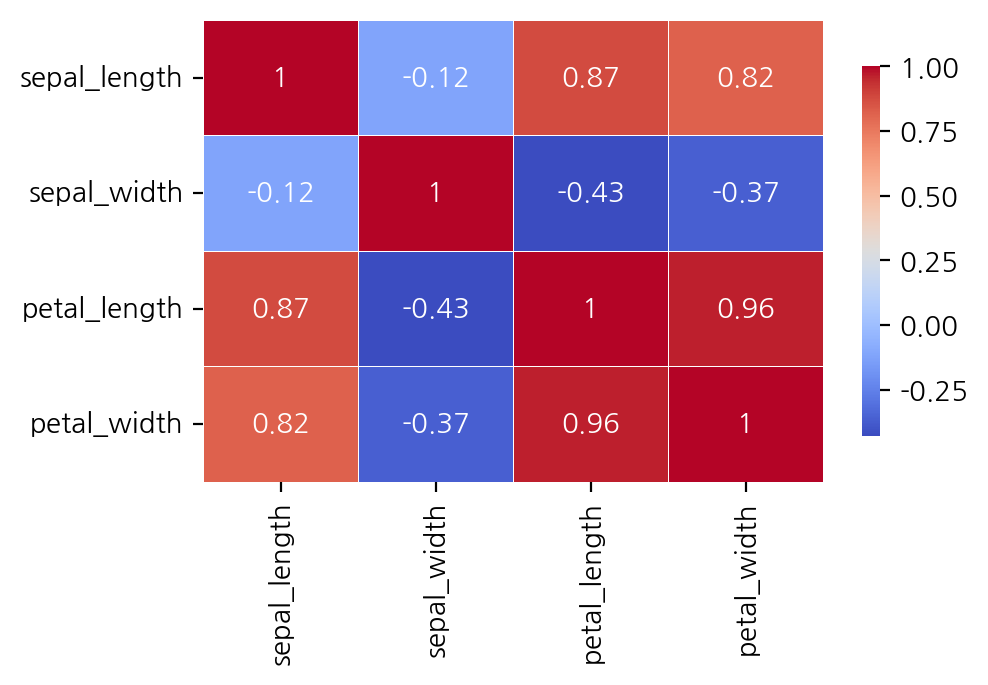

In [64]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=.2, cbar_kws={'shrink': .8})
plt.show()

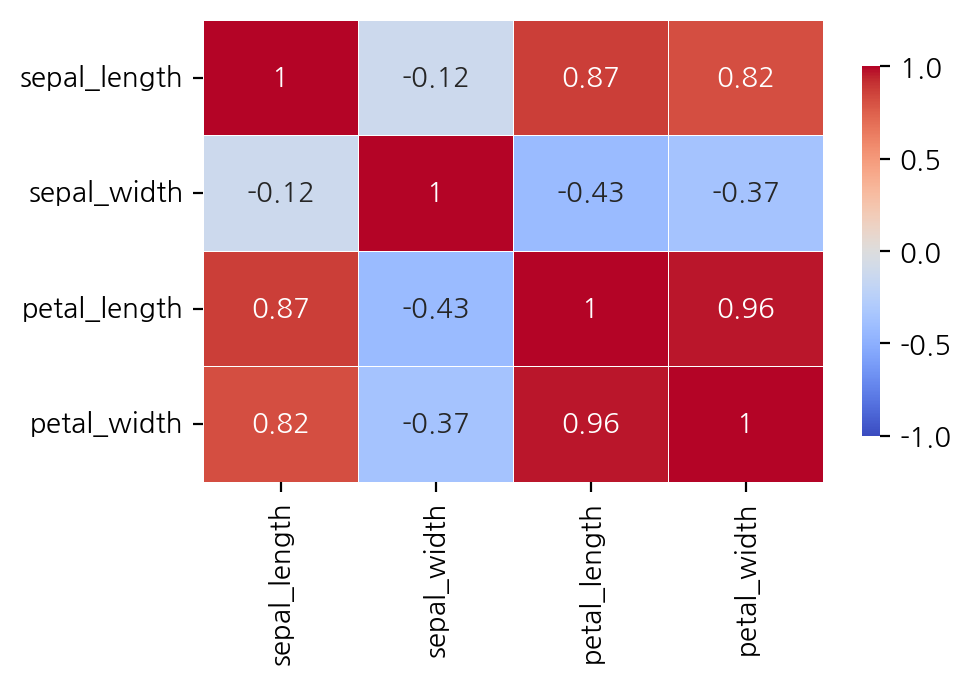

In [66]:
sns.heatmap(corr, cmap='coolwarm', annot=True,lw=.2, cbar_kws={'shrink': .8},
            vmin=-1, vmax=1)
plt.show()

In [67]:
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [68]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [69]:
mask[0, 0]

np.float64(0.0)

In [70]:
mask[[0, 1], [0, 1]]

array([0., 0.])

In [71]:
mask[[0, 0, 0, 0, 1, 1, 1, 2, 2, 3], [0, 1, 2, 3, 1, 2, 3, 2, 3, 3]]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [74]:
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [76]:
mask[1:, :-1]

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [77]:
new_mask = mask[1:, :-1]
new_mask

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [78]:
corr.iloc[1:, :-1]

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


In [79]:
display_side_by_side(corr, corr.iloc[1:, :-1])

sepal_length 
 sepal_width 
 petal_length 
 petal_width 
 
 
 
 
 sepal_length 
 1.00 
 -0.12 
 0.87 
 0.82 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 -0.37 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 0.96 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96 
 1.00 
 
 
      
 
 
 
 sepal_length 
 sepal_width 
 petal_length 
 
 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96

In [80]:
corr_new = corr.iloc[1:, :-1]
corr_new

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


In [81]:
display_side_by_side(corr, corr_new)

sepal_length 
 sepal_width 
 petal_length 
 petal_width 
 
 
 
 
 sepal_length 
 1.00 
 -0.12 
 0.87 
 0.82 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 -0.37 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 0.96 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96 
 1.00 
 
 
      
 
 
 
 sepal_length 
 sepal_width 
 petal_length 
 
 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96

<Axes: >

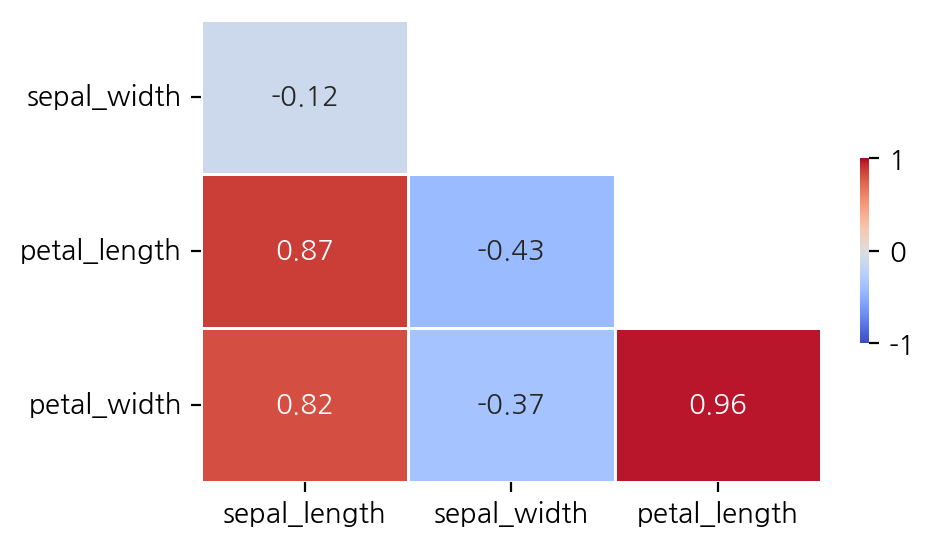

In [82]:
sns.heatmap(corr_new, annot=True, cmap='coolwarm', mask=new_mask,
            vmin=-1, vmax=1, cbar_kws = {'shrink': .4}, lw=.5)

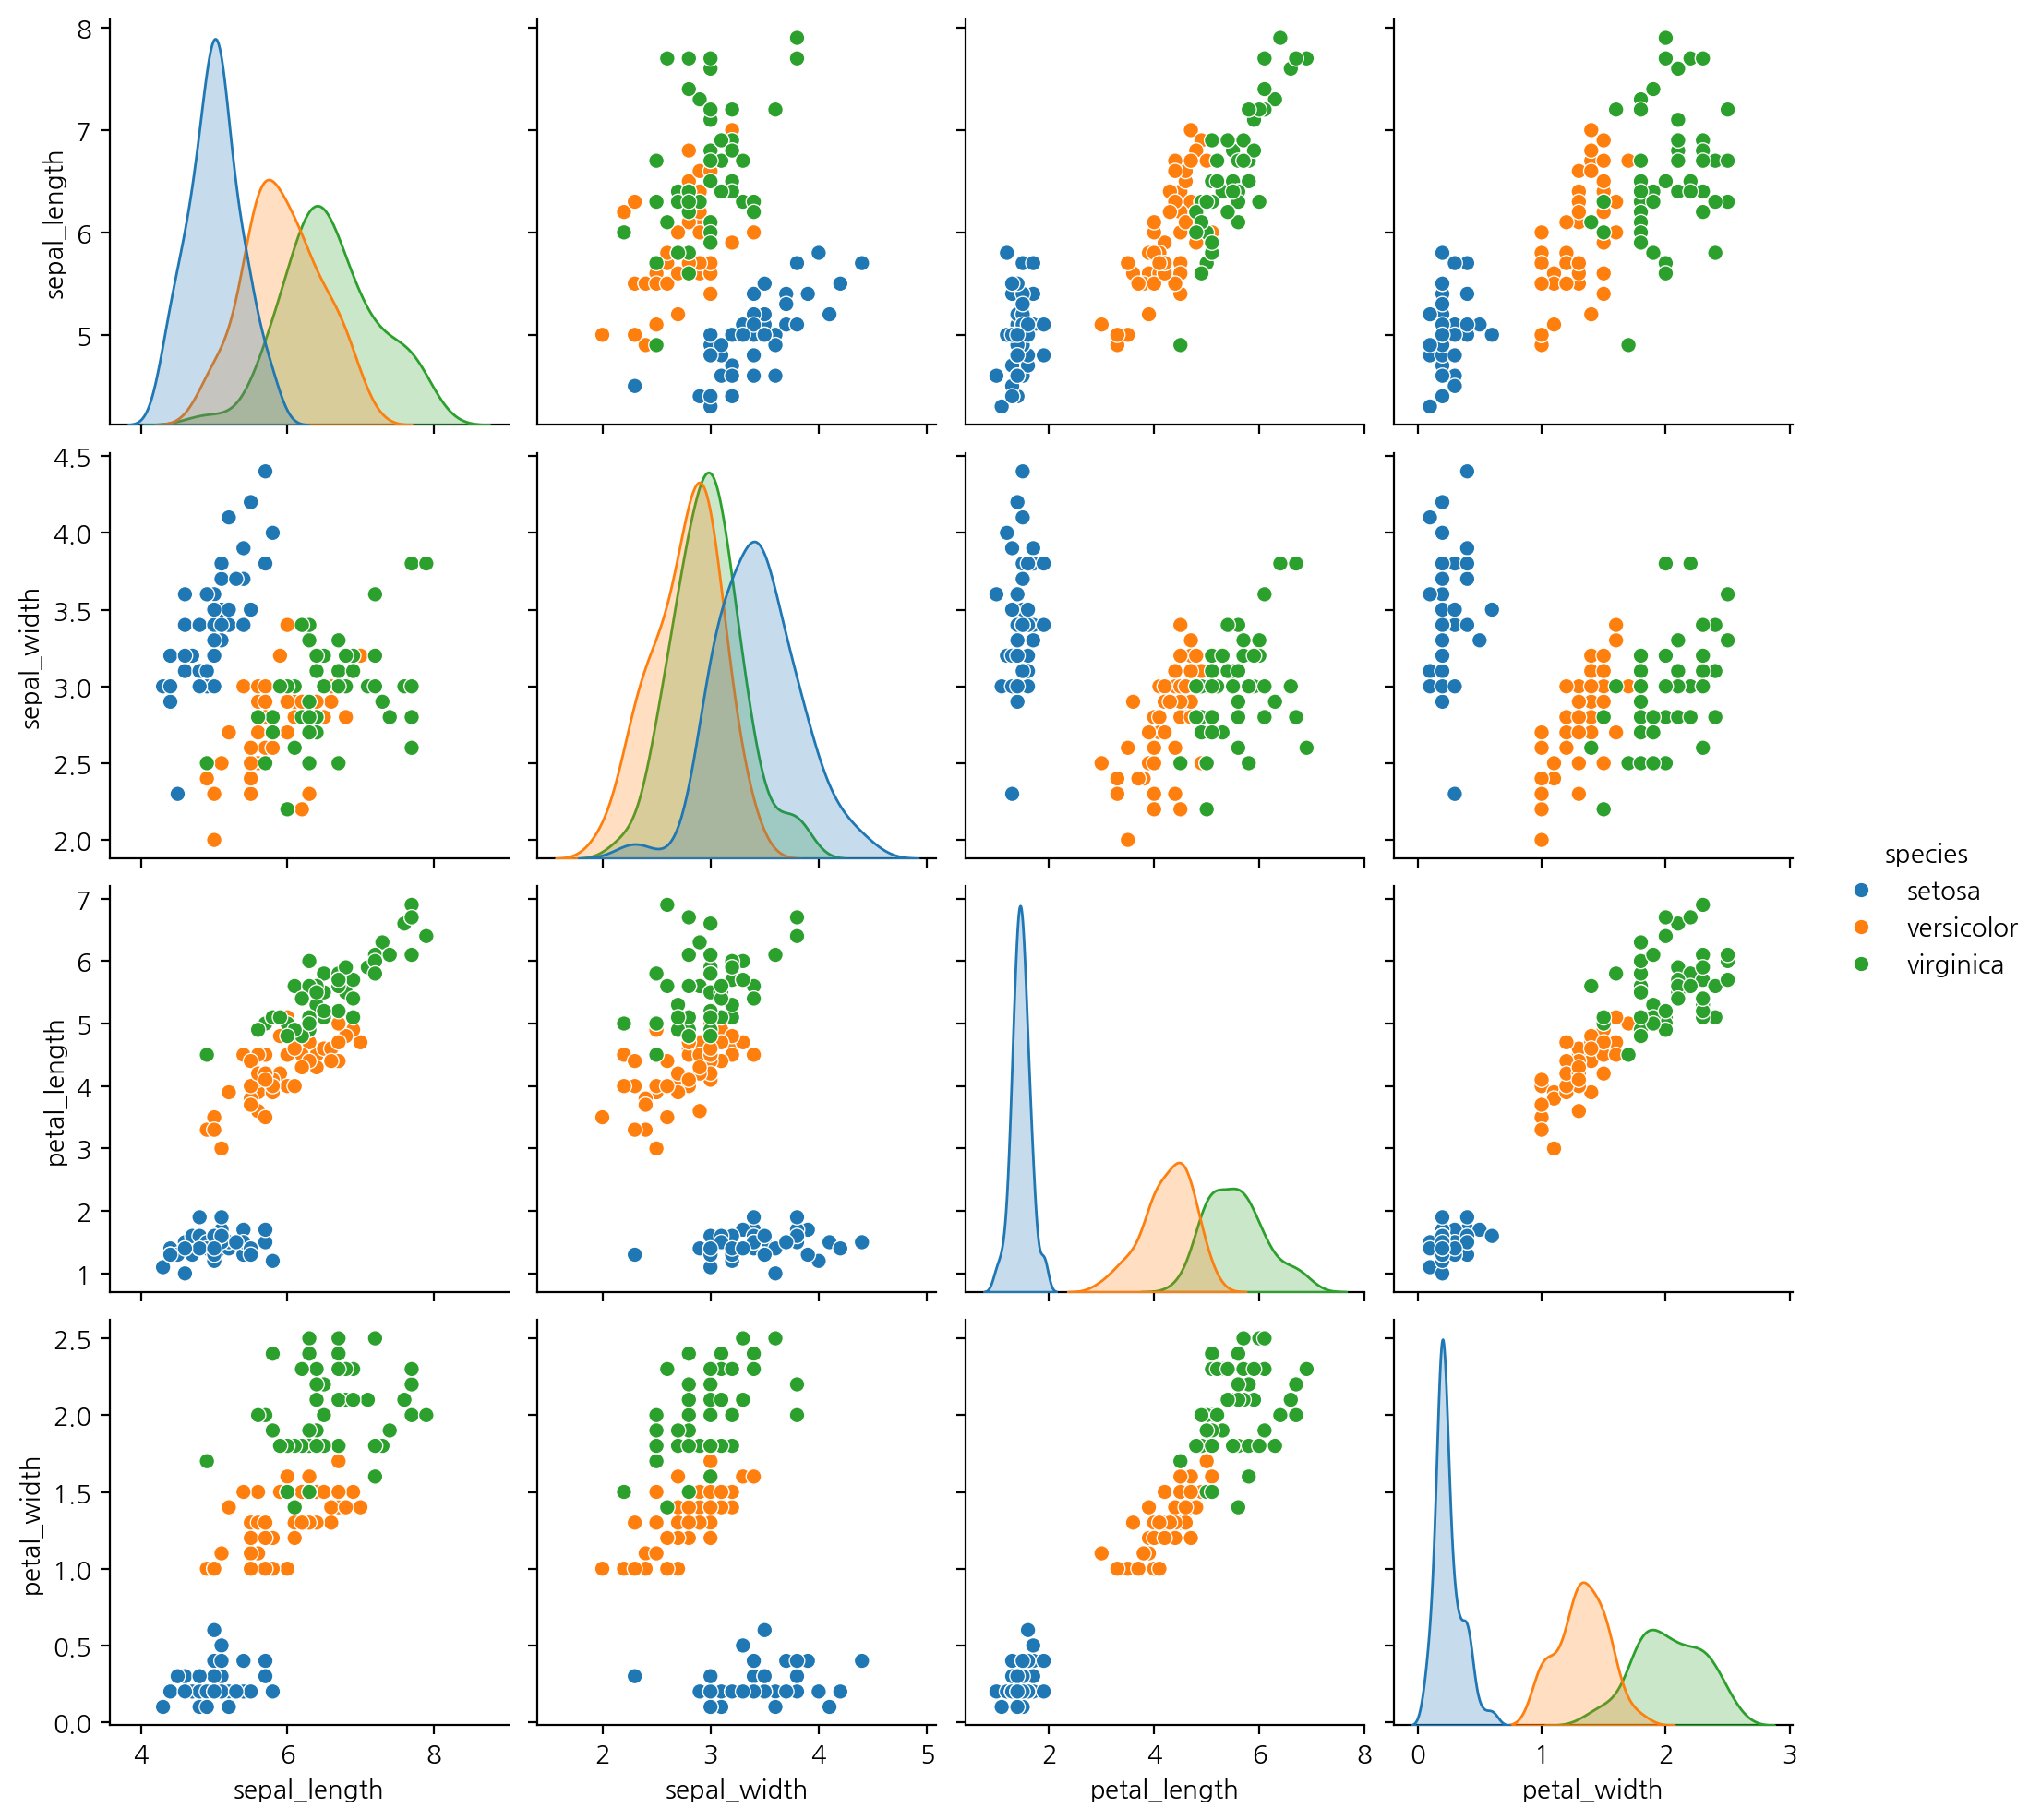

In [84]:
sns.pairplot(iris, hue='species')
plt.show()

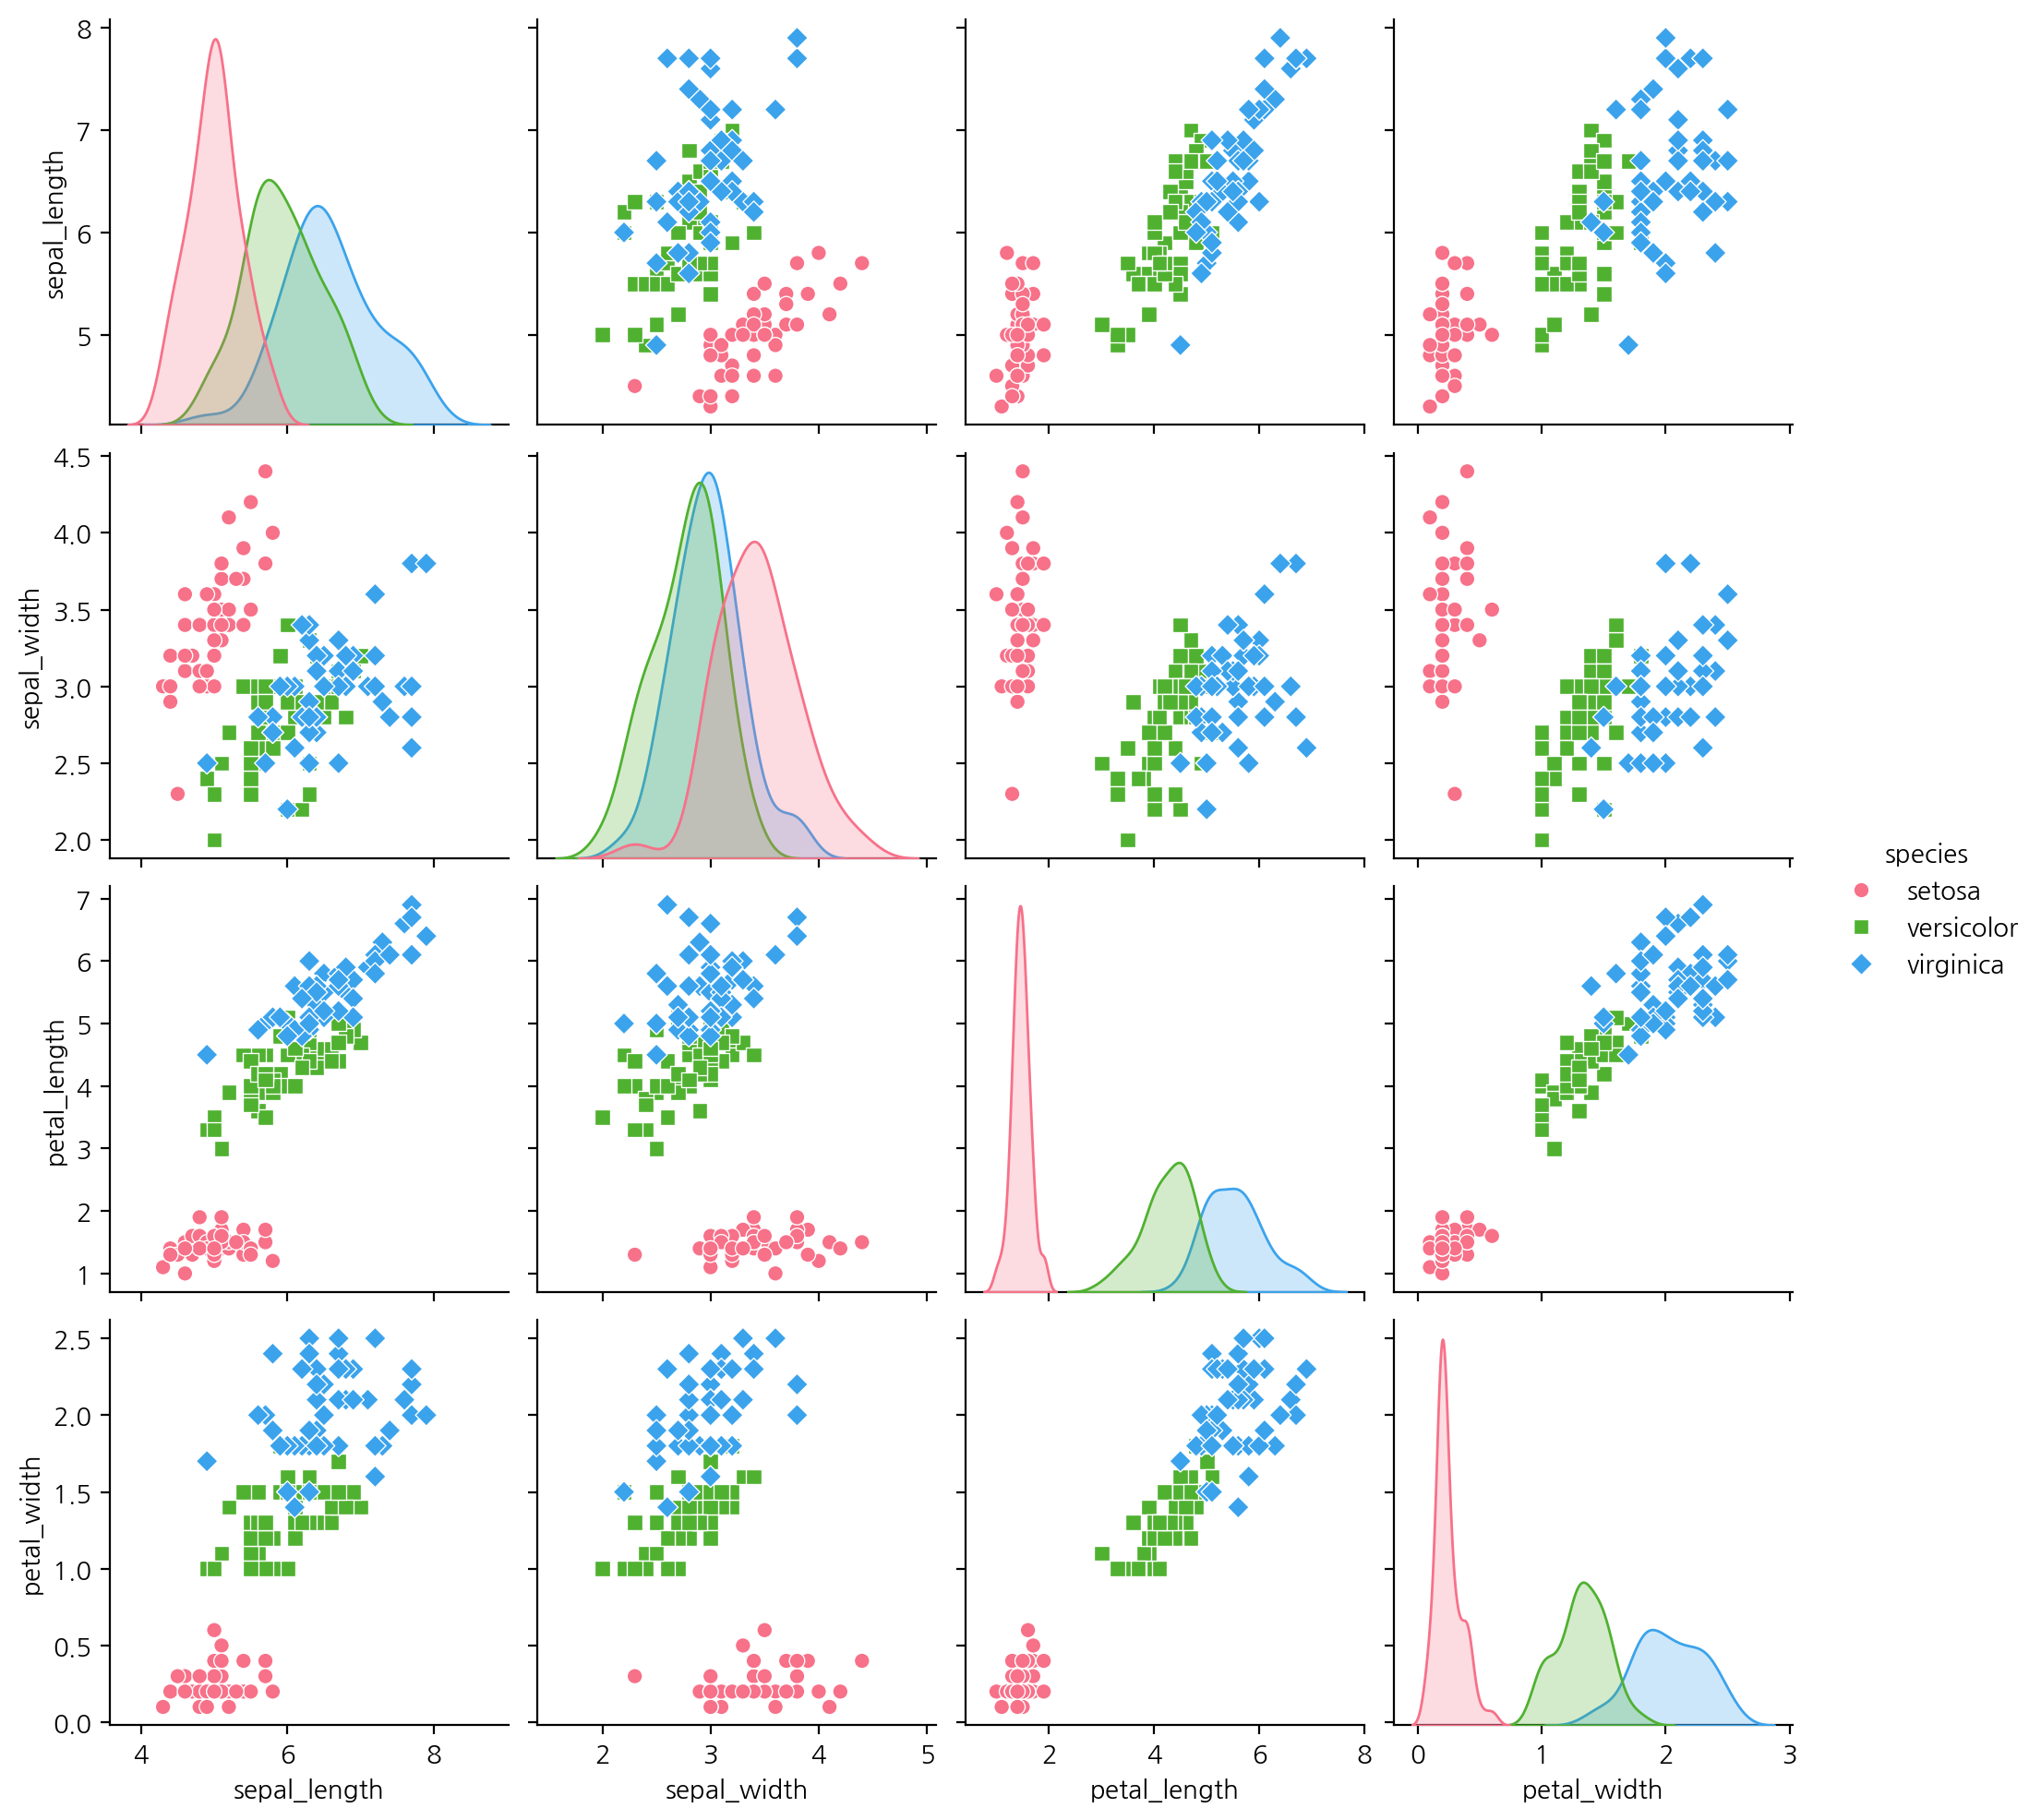

In [88]:
sns.pairplot(iris, palette='husl', hue='species', markers=['o', 's', 'D'])
plt.show()

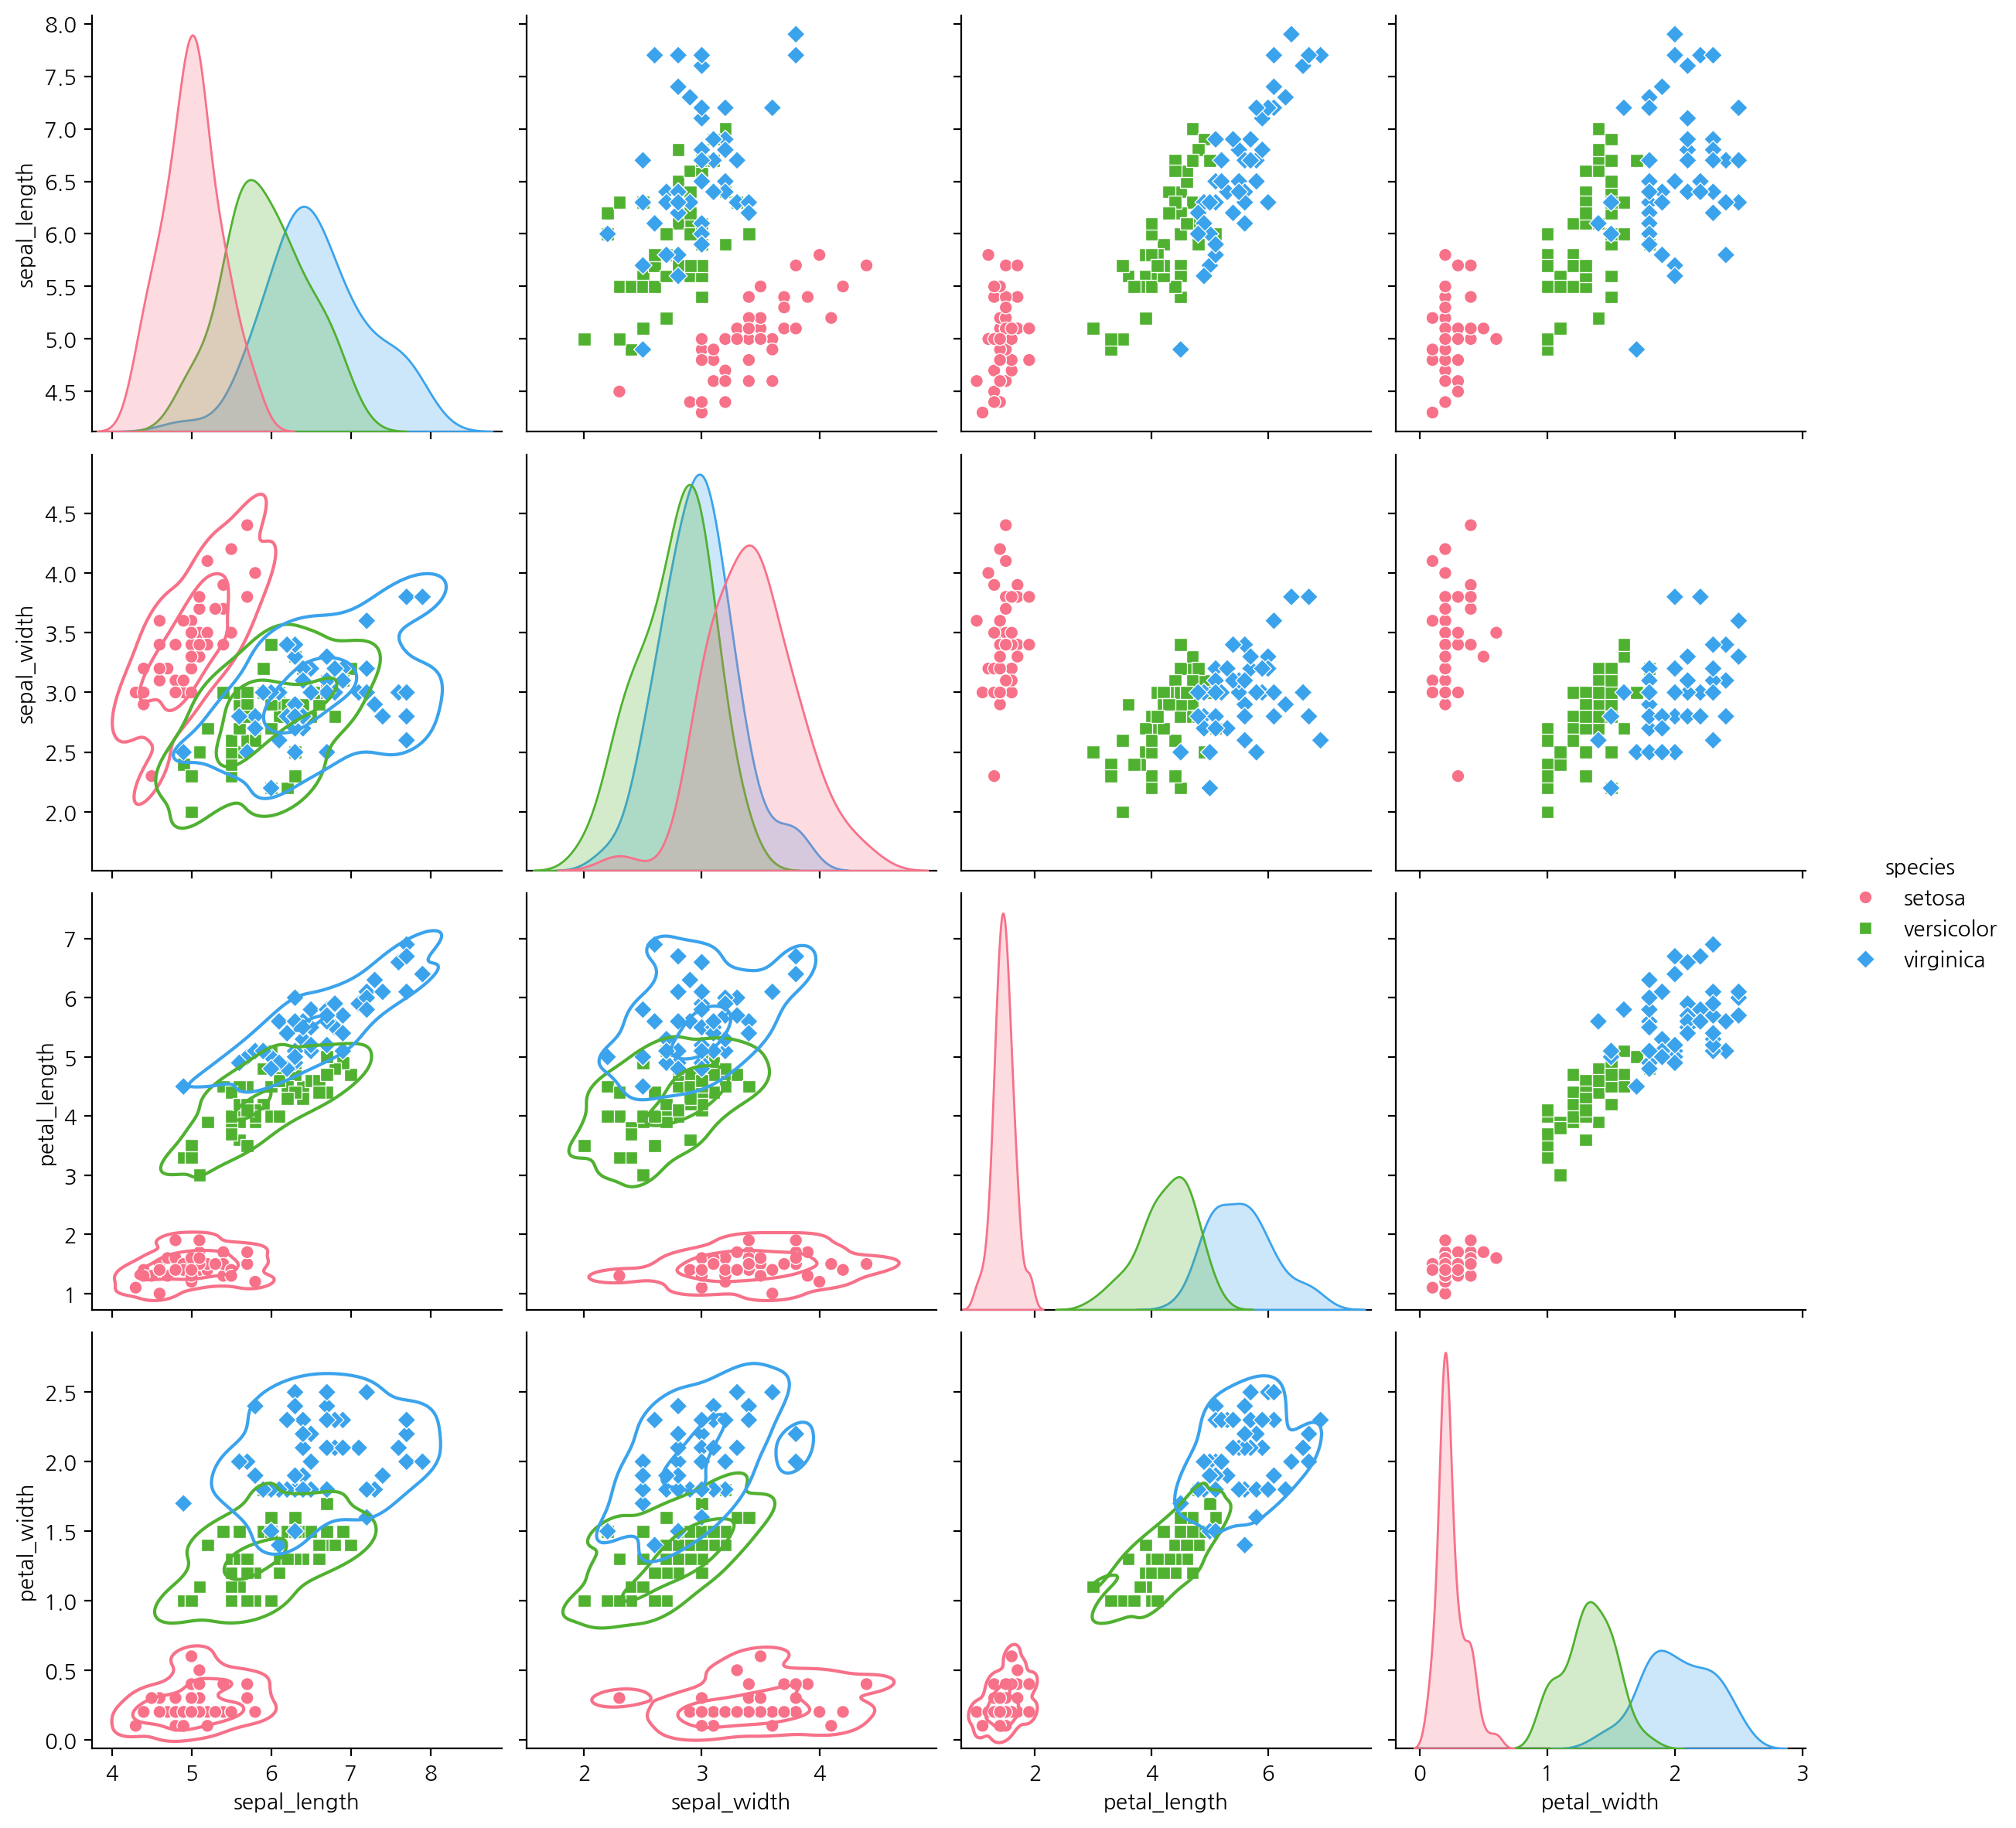

In [89]:
g = sns.pairplot(iris, hue="species", palette="husl", height=3, markers=["o", "s", "D"]);
g.map_lower(sns.kdeplot, levels=3); # 동고선의 색상, 0==검정, 1==흰색, hue 색상으로 구분 여려움

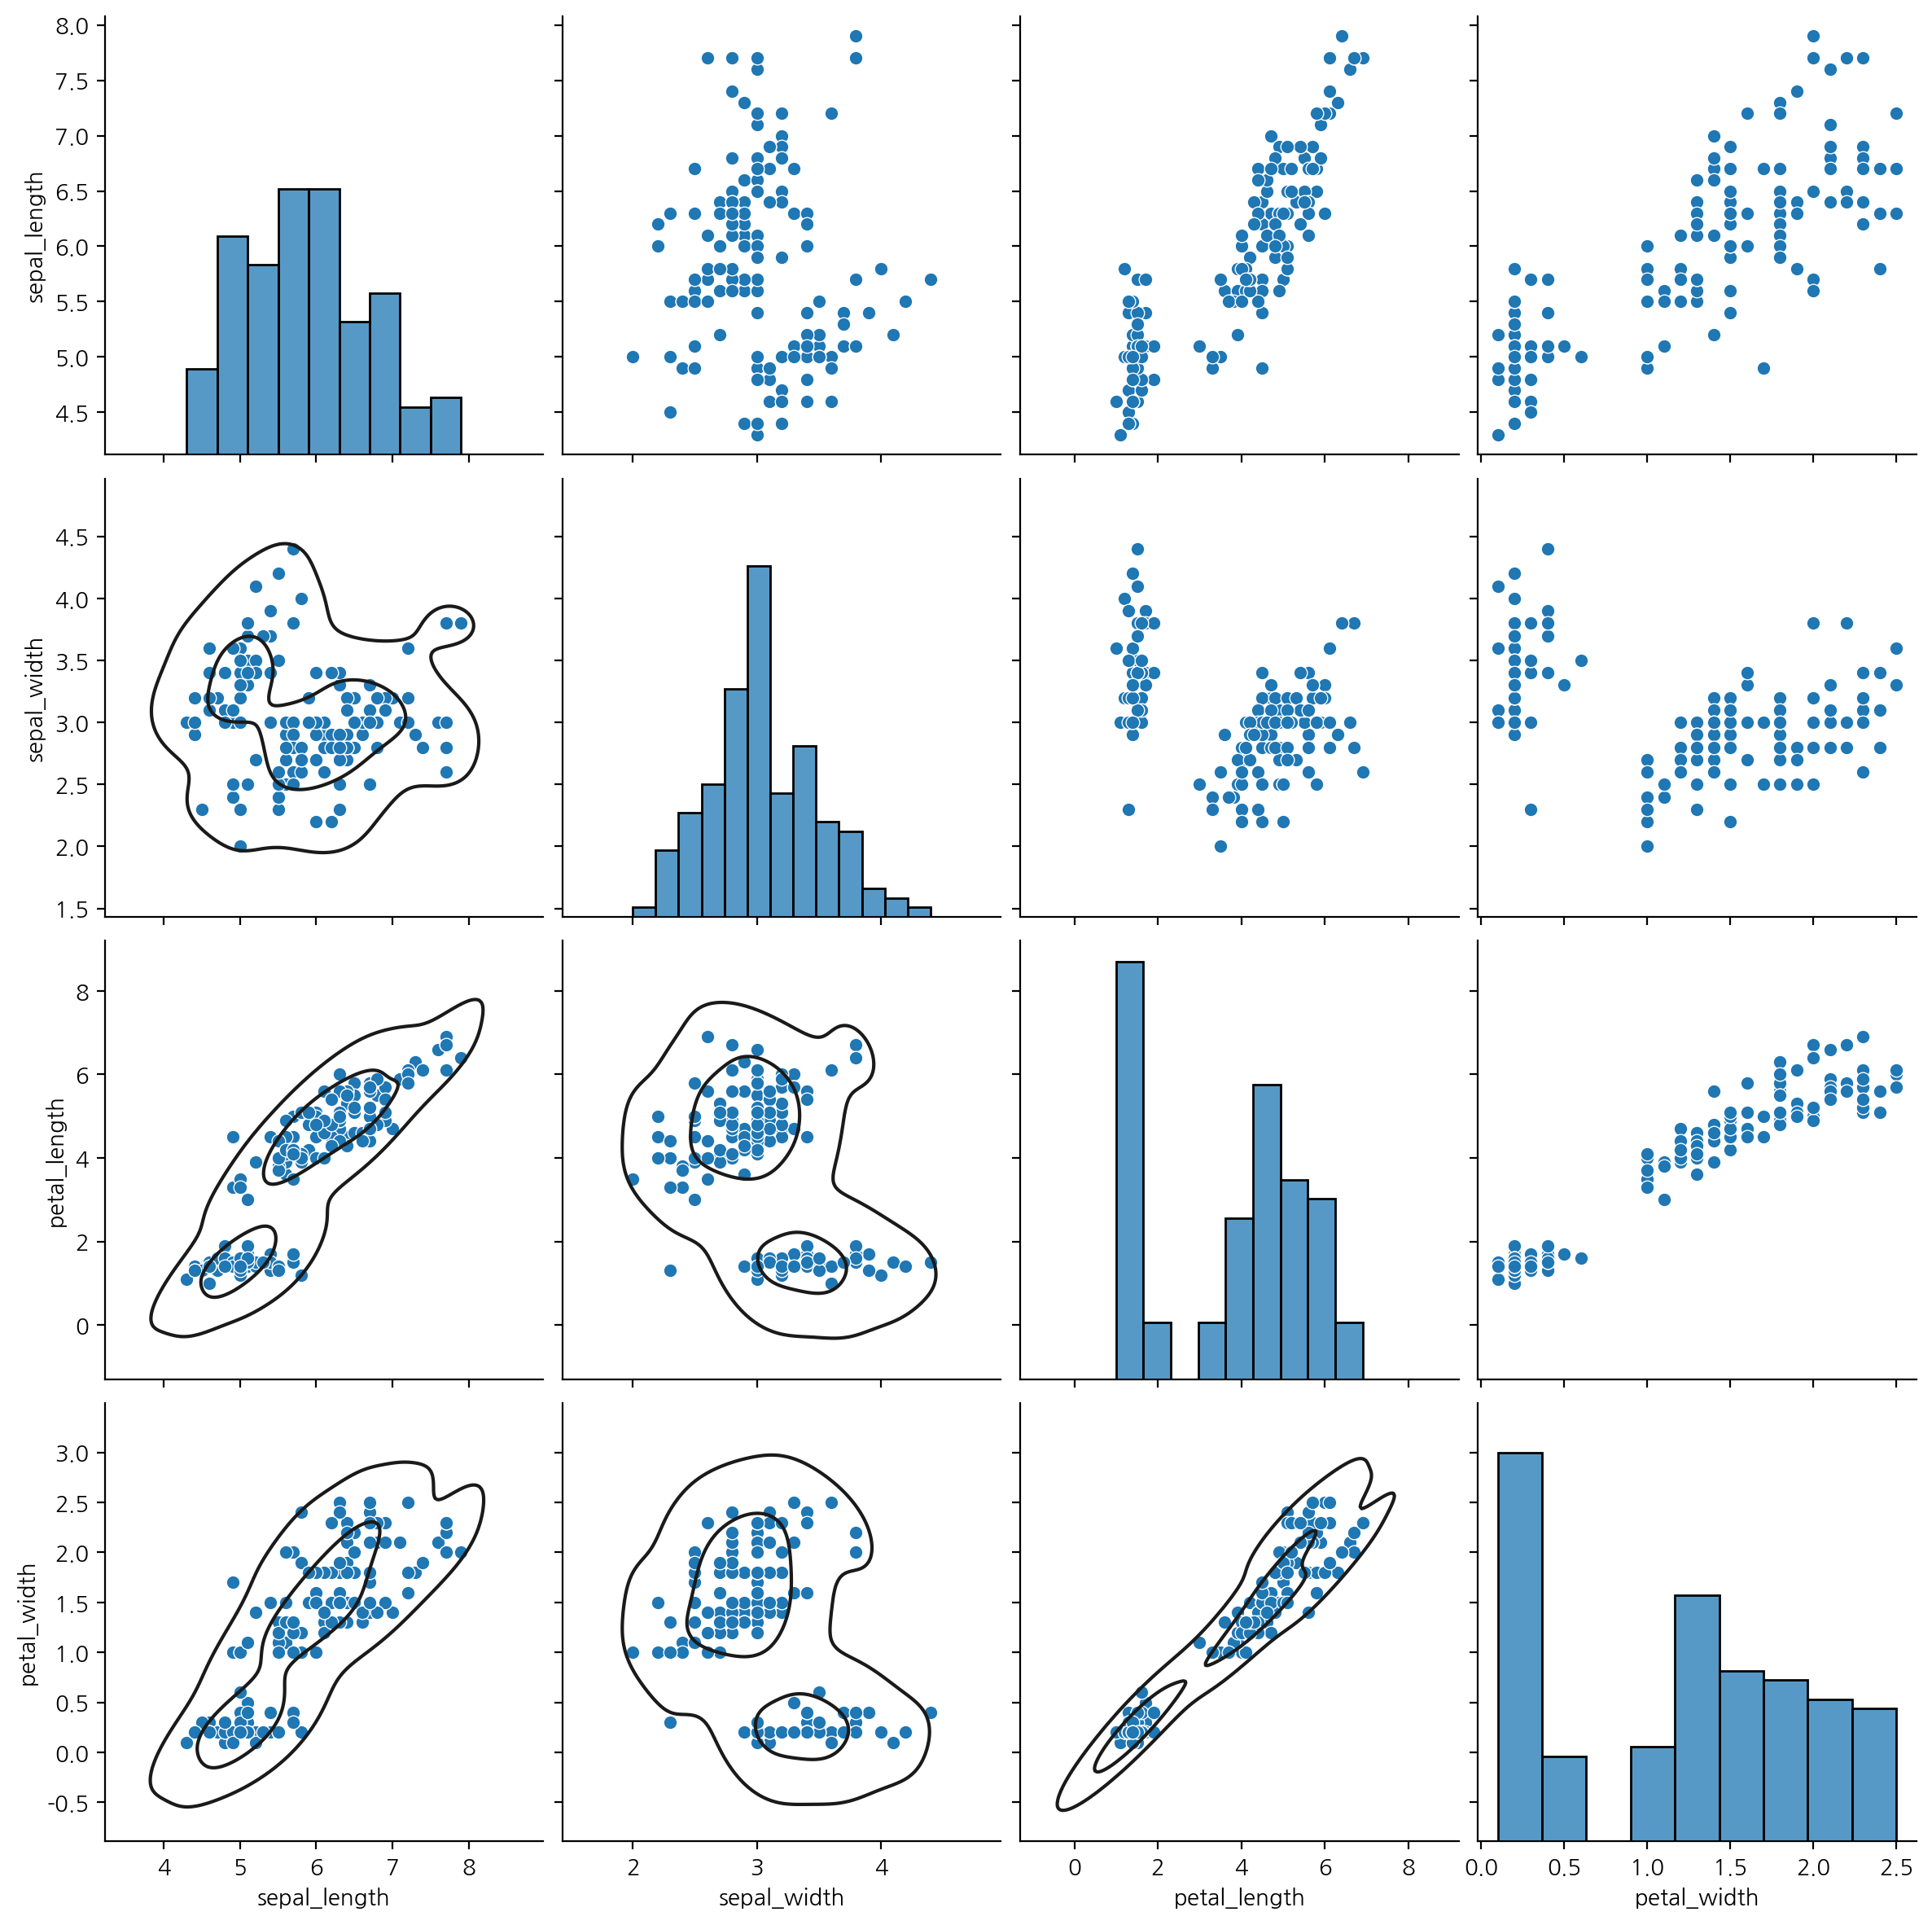

In [91]:
g = sns.pairplot(iris, height=3);
g.map_lower(sns.kdeplot, levels=3, color=".1");